# Cue-utilization alignment notebook: Court vs. LLM setups

This notebook answers:

> **To what extent does the cue-utilization policy of one or more LLM decision setups differ from the cue-utilization policy of the court judgment?**

It is designed to stay consistent with the earlier court notebook while remaining fully runnable on its own.

It uses the same core inputs:

- `dataset_ecthr_cases/ecthr_article_6_coded_cues_gpt54_mini_codebook_v4.csv`
- `dataset_ecthr_cases/ecthr_article_6_forced_decisions_gpt54nano_baseline.csv`
- `dataset_ecthr_cases/ecthr_article_6_forced_decisions_gpt54nano_externalized.csv`
- `cue_codebook_v4.csv`

Primary analyses:

1. **Actor-specific cue-utilization profiles** using ridge-regularized logistic regression
2. **Coefficient-vector alignment metrics** between court and each LLM setup
3. **Output agreement metrics** as a secondary descriptive check
4. **Pooled linear probability model (LPM)** with court-vs-LLM cue interactions for formal difference testing
5. Optional **bootstrap intervals** for policy-alignment metrics

## Why pooled LPM instead of pooled logit?

The pooled interaction model is used here to test whether a cue is weighted differently by the LLM than by the court. For that purpose, a **linear probability model with case-clustered standard errors** is often easier to estimate, easier to interpret, and less fragile than a pooled interaction logit. The main actor-specific policy profiles still come from **ridge-logit** models.

## What to treat as primary evidence

For a paper on cue-utilization alignment, the primary evidence is:

- **coefficient similarity metrics**
- **cue-specific interaction differences** and the pooled global interaction test
- **propensity correlation** between court and LLM cue-based prediction tendencies

Raw output agreement is useful, but it is **secondary**. An LLM can match outcomes while using a different cue policy.

### What the next cell does

This cell sets the notebook's **configuration and file-path assumptions**.

Why this cell matters:
- it defines which data files are read, which decision columns are compared, and which screening rules are used
- these settings determine the scope of every downstream analysis, so they should be checked before interpreting results

In [20]:
# --- Configuration ---
from pathlib import Path

DATA_DIR = Path('dataset_ecthr_cases')
CUES_PATH = DATA_DIR / 'ecthr_balanced_A6_coded_cues_gpt54_mini_codebook_v4.csv'
DECISIONS_PATH_BASELINE = DATA_DIR / 'ecthr_balanced_A6_forced_decisions_mistral-large_baseline.csv'
DECISIONS_PATH_EXTERNALIZED = DATA_DIR / 'ecthr_balanced_A6_forced_decisions_mistral-large_court-externalized.csv'
DECISIONS_PATH_INTROSPECTIVE = DATA_DIR / 'ecthr_balanced_A6_forced_decisions_mistral-large_introspective-externalized.csv'
CODEBOOK_PATH = Path('cue_codebook_v4.csv')

CASE_ID_COL = 'case_id'
COURT_COL = 'court_decision_6_violated'

LLM_RUN_SPECS = {
    'LLM_baseline_decision_6_violated': {
        'path': DECISIONS_PATH_BASELINE,
        'label': 'Mistral Large baseline',
    },
    'LLM_externalized_decision_6_violated': {
        'path': DECISIONS_PATH_EXTERNALIZED,
        'label': 'Mistral Large externalized',
    },
    'LLM_introspective_decision_6_violated': {
        'path': DECISIONS_PATH_INTROSPECTIVE,
        'label': 'Mistral Large introspective',
    },
}

LLM_COLS_OVERRIDE = list(LLM_RUN_SPECS)
LLM_LABELS = {col: spec['label'] for col, spec in LLM_RUN_SPECS.items()}

MIN_CLASS_COUNT = 5
N_CASES = None
RANDOM_STATE = 42
N_SPLITS = 5
CS_GRID = None

### What the next cell does

This cell loads the **libraries required for the full notebook workflow**.

Why this cell matters:
- the later cells use statistical modeling, similarity metrics, plotting, and notebook display utilities
- keeping imports in one place makes it clear which packages the notebook depends on

In [21]:
# --- Imports ---
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

from IPython.display import Markdown, display

from scipy.spatial.distance import cosine
from scipy.stats import pearsonr, spearmanr

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    log_loss,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

if CS_GRID is None:
    CS_GRID = np.logspace(-3, 3, 25)
else:
    CS_GRID = np.asarray(CS_GRID, dtype=float)

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)


## 1. Load and preprocess data

This section mirrors the earlier notebook logic as closely as possible while making the notebook self-contained.

### What it does

- loads the coded cue file and the codebook
- loads the **baseline** and **externalized** LLM decision files
- renames and harmonizes those decision columns so each run is treated as a separate LLM setup
- merges the decision runs with the cue table on `case_id`
- recodes court / LLM decisions and binary cues into consistent 0/1 columns
- selects the usable binary cues with enough 1s and 0s for stable modeling

### Important interpretation note

If the cue columns are coded as **observability indicators** (`1 = explicitly observable in the summary`, `0 = not observable in the summary`), then the analyses below concern **alignment in the use of observable summary cues**, not necessarily alignment in the use of the full underlying legal facts.

### What the next cell runs

This cell runs the **data loading, preprocessing, and cue-screening pipeline**.

Why this cell matters:
- court and LLM models must be estimated on the same merged case set and the same cue matrix
- this cell reconstructs the decision columns when needed, harmonizes binary coding, and screens cues for enough variation
- any change here changes the analysis sample, so this is one of the most important cells for reproducibility

In [22]:
TARGET_TRUE_TOKENS = {'1', 'true', 'yes', 'y', 'violated', 'violation'}
TARGET_FALSE_TOKENS = {'0', 'false', 'no', 'n', 'not_violated', 'not violated', 'no_violation'}
BINARY_ONE_TOKENS = {'1', 'true', 'yes', 'y'}
BINARY_ZERO_TOKENS = {'0', 'false', 'no', 'n', '', 'nan', 'none', 'null', 'unk', 'unknown', 'n/a', 'na'}

if not CUES_PATH.exists():
    raise FileNotFoundError(f'Missing coded cue file: {CUES_PATH}')
if not CODEBOOK_PATH.exists():
    raise FileNotFoundError(f'Missing codebook file: {CODEBOOK_PATH}')
missing_decision_paths = [str(spec['path']) for spec in LLM_RUN_SPECS.values() if not spec['path'].exists()]
if missing_decision_paths:
    raise FileNotFoundError(
        'Missing one or more LLM decision files: ' + ', '.join(missing_decision_paths)
    )


def _clean_string(series):
    return series.astype('string').str.strip().str.lower()


def parse_binary_target(series, series_name=None):
    series_name = series_name or getattr(series, 'name', 'target')
    if pd.api.types.is_bool_dtype(series):
        return series.astype(int)

    numeric = pd.to_numeric(series, errors='coerce')
    valid_numeric = numeric.dropna()
    if not valid_numeric.empty and set(valid_numeric.unique()).issubset({0, 1}):
        out = numeric.astype('Int64')
        if out.isna().any():
            bad = sorted(series[out.isna()].astype(str).unique().tolist())
            raise ValueError(f'Unexpected target values in {series_name}: {bad}')
        return out.astype(int)

    cleaned = _clean_string(series)
    mapped = cleaned.map(
        lambda value: 1 if value in TARGET_TRUE_TOKENS else 0 if value in TARGET_FALSE_TOKENS else pd.NA
    )
    if mapped.isna().any():
        bad = sorted(cleaned[mapped.isna()].dropna().unique().tolist())
        raise ValueError(f'Unexpected target values in {series_name}: {bad}')
    return mapped.astype(int)


def recode_binary_cue(series):
    if pd.api.types.is_bool_dtype(series):
        return series.astype(float)

    numeric = pd.to_numeric(series, errors='coerce')
    valid_numeric = numeric.dropna()
    if not valid_numeric.empty and set(valid_numeric.unique()).issubset({0, 1}):
        return numeric.astype(float)

    cleaned = _clean_string(series).fillna('')
    mapped = cleaned.map(
        lambda value: 1 if value in BINARY_ONE_TOKENS else 0 if value in BINARY_ZERO_TOKENS else pd.NA
    )
    if mapped.isna().any():
        bad = sorted(cleaned[mapped.isna()].unique().tolist())
        raise ValueError(f'Unexpected binary cue values in {series.name}: {bad}')
    return mapped.astype(float)


def infer_llm_cols(df):
    if LLM_COLS_OVERRIDE is not None:
        missing = [c for c in LLM_COLS_OVERRIDE if c not in df.columns]
        if missing:
            raise ValueError(f'LLM_COLS_OVERRIDE contains columns not found in the decisions data: {missing}')
        return list(LLM_COLS_OVERRIDE)

    candidates = []
    for col in df.columns:
        if col == COURT_COL:
            continue
        if col.endswith('decision_6_violated') or (col.startswith('LLM_') and col.endswith('_violated')):
            candidates.append(col)

    seen = set()
    ordered = []
    for col in candidates:
        if col not in seen:
            seen.add(col)
            ordered.append(col)
    return ordered


codebook_df = pd.read_csv(CODEBOOK_PATH)
cue_id_col = 'cue_id' if 'cue_id' in codebook_df.columns else 'cue'
cue_name_col = 'cue_name' if 'cue_name' in codebook_df.columns else cue_id_col
cue_family_col = 'family' if 'family' in codebook_df.columns else None
cue_type_col = 'type' if 'type' in codebook_df.columns else None

if cue_type_col is not None:
    binary_codebook = codebook_df[codebook_df[cue_type_col].fillna('binary').astype(str).str.lower() == 'binary'].copy()
else:
    binary_codebook = codebook_df.copy()

cue_name_map = dict(zip(binary_codebook[cue_id_col], binary_codebook[cue_name_col]))
cue_family_map = dict(zip(binary_codebook[cue_id_col], binary_codebook[cue_family_col])) if cue_family_col else {}
codebook_cues = [cue for cue in binary_codebook[cue_id_col].tolist()]

cue_source_df = pd.read_csv(CUES_PATH)
if COURT_COL in cue_source_df.columns:
    cue_source_df[COURT_COL] = parse_binary_target(cue_source_df[COURT_COL], COURT_COL)

# Build one combined decisions table from the two nano runs.
decisions_df = cue_source_df[[CASE_ID_COL, COURT_COL]].copy()
decision_sources = []
for llm_col, spec in LLM_RUN_SPECS.items():
    run_df = pd.read_csv(spec['path']).drop_duplicates(subset=[CASE_ID_COL], keep='first').copy()
    if CASE_ID_COL not in run_df.columns:
        raise ValueError(f"{spec['path']} is missing required column: {CASE_ID_COL}")

    if llm_col in run_df.columns:
        llm_series = parse_binary_target(run_df[llm_col], llm_col)
    elif 'predicted_decision_6' in run_df.columns:
        llm_series = parse_binary_target(run_df['predicted_decision_6'], f"{spec['path'].name}: predicted_decision_6")
    else:
        raise ValueError(
            f"{spec['path']} must contain either {llm_col} or predicted_decision_6."
        )

    run_keep = pd.DataFrame({
        CASE_ID_COL: run_df[CASE_ID_COL],
        llm_col: llm_series,
    })
    decisions_df = decisions_df.merge(run_keep, on=CASE_ID_COL, how='left', validate='one_to_one')
    decision_sources.append(str(spec['path']))

LLM_COLS = infer_llm_cols(decisions_df)
for col in [COURT_COL] + LLM_COLS:
    decisions_df[col] = parse_binary_target(decisions_df[col], col)
    if col != COURT_COL:
        LLM_LABELS.setdefault(col, col)

decisions_source_label = ' + '.join(decision_sources)

# Keep the cue matrix tied to the codebook. Fall back to non-metadata columns only if needed.
candidate_cue_cols = [cue for cue in codebook_cues if cue in cue_source_df.columns]
if not candidate_cue_cols:
    protected = {CASE_ID_COL, COURT_COL, *LLM_COLS}
    metadata_like = {
        'case_no', 'title', 'judgment_date', 'split', 'allegedly_violated_articles', 'violated_articles'
    }
    candidate_cue_cols = [
        c for c in cue_source_df.columns
        if c not in protected and c not in metadata_like
    ]

if not candidate_cue_cols:
    raise ValueError('No cue columns were identified for analysis.')

# Drop duplicate cases defensively before merging.
decisions_df = decisions_df.drop_duplicates(subset=[CASE_ID_COL], keep='first').copy()
cue_source_df = cue_source_df.drop_duplicates(subset=[CASE_ID_COL], keep='first').copy()

cue_matrix = pd.DataFrame(
    {cue: recode_binary_cue(cue_source_df[cue]) for cue in candidate_cue_cols},
    index=cue_source_df.index,
)
cue_ready_df = pd.concat([cue_source_df[[CASE_ID_COL]].copy(), cue_matrix], axis=1)

analysis_df = decisions_df[[CASE_ID_COL, COURT_COL] + LLM_COLS].merge(
    cue_ready_df,
    on=CASE_ID_COL,
    how='inner',
    validate='one_to_one',
)

if CASE_ID_COL in analysis_df.columns:
    analysis_df = analysis_df.sort_values(CASE_ID_COL).reset_index(drop=True)
if N_CASES is not None:
    analysis_df = analysis_df.head(N_CASES).copy()

cue_screen_rows = []
selected_cues = []
for cue in candidate_cue_cols:
    x = analysis_df[cue].dropna()
    n1 = int((x == 1).sum())
    n0 = int((x == 0).sum())
    keep = (n1 >= MIN_CLASS_COUNT) and (n0 >= MIN_CLASS_COUNT)
    cue_screen_rows.append({
        'cue': cue,
        'cue_name': cue_name_map.get(cue, cue),
        'family': cue_family_map.get(cue, ''),
        'n_nonmissing': int(x.shape[0]),
        'n_observable': n1,
        'n_not_observable': n0,
        'observable_share': float(x.mean()) if len(x) else np.nan,
        'min_class_count': min(n0, n1),
        'selected': keep,
    })
    if keep:
        selected_cues.append(cue)

if not selected_cues:
    raise ValueError('No binary cues passed the screening criteria. Relax MIN_CLASS_COUNT and rerun.')

CUE_COLS = selected_cues
cue_screen_df = pd.DataFrame(cue_screen_rows).sort_values(
    ['selected', 'observable_share', 'cue'],
    ascending=[False, False, True],
).reset_index(drop=True)

analysis_df = analysis_df[[CASE_ID_COL, COURT_COL] + LLM_COLS + CUE_COLS].copy()
analysis_df = analysis_df.dropna(subset=[COURT_COL] + LLM_COLS).reset_index(drop=True)

X_all = analysis_df[CUE_COLS].copy()
DECISION_DF = analysis_df[[CASE_ID_COL, COURT_COL] + LLM_COLS].copy()
CUE_DF = analysis_df[CUE_COLS].copy()

print(f'Decisions source: {decisions_source_label}')
print(f'Merged cases available for court-vs-LLM comparison: {len(analysis_df)}')
print(f'Detected LLM setups: {LLM_COLS}')
print(f'Selected {len(CUE_COLS)} cues after screening.')

display(pd.DataFrame({
    'column': [COURT_COL] + LLM_COLS,
    'n_nonmissing': [analysis_df[c].notna().sum() for c in [COURT_COL] + LLM_COLS],
    'mean': [analysis_df[c].mean() for c in [COURT_COL] + LLM_COLS],
    'n_unique_nonmissing': [analysis_df[c].dropna().nunique() for c in [COURT_COL] + LLM_COLS],
}))

display(cue_screen_df.head(20))
display(analysis_df.head(3))

Decisions source: dataset_ecthr_cases/ecthr_balanced_A6_forced_decisions_mistral-large_baseline.csv + dataset_ecthr_cases/ecthr_balanced_A6_forced_decisions_mistral-large_court-externalized.csv + dataset_ecthr_cases/ecthr_balanced_A6_forced_decisions_mistral-large_introspective-externalized.csv
Merged cases available for court-vs-LLM comparison: 1000
Detected LLM setups: ['LLM_baseline_decision_6_violated', 'LLM_externalized_decision_6_violated', 'LLM_introspective_decision_6_violated']
Selected 45 cues after screening.


,column,n_nonmissing,mean,n_unique_nonmissing
0,court_decision_6_violated,1000,0.500,2
1,LLM_baseline_decision_6_violated,1000,0.708,2
2,LLM_externalized_decision_6_violated,1000,0.978,2
3,LLM_introspective_decision_6_violated,1000,0.987,2


,cue,cue_name,family,n_nonmissing,n_observable,n_not_observable,observable_share,min_class_count,selected
0,B1,Duration computable from summary,Delay,1000,970,30,0.970,30,True
1,A3,Multiple procedural levels reported,CasePosture,1000,954,46,0.954,46,True
2,C4,Review by higher or reviewing court addressed,AccessToJustice,1000,830,170,0.830,170,True
3,B2,Excessive proceedings duration reported,Delay,1000,717,283,0.717,283,True
4,H1,Reasons for decision addressed in summary,DecisionForm,1000,640,360,0.640,360,True
5,E7,Serious charge or high-stakes consequence repo...,Participation,1000,541,459,0.541,459,True
6,A1,Criminal case reported,CasePosture,1000,409,591,0.409,409,True
7,C1,Public hearing addressed in summary,AccessToJustice,1000,365,635,0.365,365,True
8,B5,Case complexity reported,Delay,1000,351,649,0.351,351,True
9,B4,Applicant contributed to delay reported,Delay,1000,294,706,0.294,294,True


,case_id,court_decision_6_violated,LLM_baseline_decision_6_violated,LLM_externalized_decision_6_violated,LLM_introspective_decision_6_violated,A1,A2,A3,A4,A5,B1,B2,B3,B4,B5,C1,C2,C3,C4,C5,D1,D2,D3,D4,D5,E1,E2,E3,E4,E6,E7,F1,F2,F3,F4,F5,F6,F7,F8,F9,G1,G2,G3,G4,G5,H1,H2,I1,I2,I3
0,001-100036,0,1,1,1,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1,001-100393,0,0,1,1,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,001-100407,0,0,1,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


## 2. Helper functions

### Design overview

- **Ridge-logit** is used to estimate actor-specific cue-utilization profiles for the court and each LLM setup.
- **Coefficient alignment metrics** compare those profiles directly.
- **Output agreement metrics** are included as a secondary check.
- **Pooled LPM with case-clustered standard errors** formally tests whether the LLM weights a cue differently from the court.

### Main metrics to focus on

- **coefficient-vector Pearson correlation**: overall similarity in signed cue weights
- **cosine similarity**: geometric similarity of the full weight vectors
- **sign agreement**: whether court and LLM push cues in the same direction
- **top-k overlap**: whether they prioritize the same cues
- **pooled interaction p-values / q-values**: formal cue-by-cue difference tests
- **output kappa / MCC**: secondary outcome-level agreement checks

### What the next cell runs

This cell defines the notebook's **helper and modeling functions**.

Why this cell matters:
- it centralizes the core modeling logic so the same procedure is used for court and LLM analyses
- it defines the **ridge-logit** estimation functions, alignment metrics, and the pooled **LPM** interaction test
- keeping these functions in one place makes the analysis more consistent and easier to audit

In [23]:
def has_two_classes(y):
    return pd.Series(y).dropna().nunique() >= 2


def safe_metric(metric_fn, *args, **kwargs):
    try:
        return float(metric_fn(*args, **kwargs))
    except Exception:
        return np.nan


def get_safe_n_splits(y, requested=N_SPLITS):
    counts = pd.Series(y).value_counts(dropna=True)
    if len(counts) < 2:
        raise ValueError('Outcome must contain at least two classes for stratified CV.')
    return max(2, min(int(requested), int(counts.min())))


def build_ridge_logit_pipeline(y):
    inner_cv = StratifiedKFold(
        n_splits=get_safe_n_splits(y),
        shuffle=True,
        random_state=RANDOM_STATE,
    )
    return Pipeline(
        steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('scaler', StandardScaler()),
            (
                'model',
                LogisticRegressionCV(
                    Cs=CS_GRID,
                    cv=inner_cv,
                    penalty='l2',
                    scoring='roc_auc',
                    solver='lbfgs',
                    max_iter=5000,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )


def get_cv_predictions(X, y):
    n_splits = get_safe_n_splits(y)
    outer_cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    pipe = build_ridge_logit_pipeline(y)
    prob = cross_val_predict(pipe, X, y, cv=outer_cv, method='predict_proba')[:, 1]
    pred = (prob >= 0.5).astype(int)
    return prob, pred


def compute_binary_metrics(y_true, y_prob, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        'n': int(len(y_true)),
        'prevalence': float(np.mean(y_true)),
        'roc_auc': safe_metric(roc_auc_score, y_true, y_prob),
        'avg_precision': safe_metric(average_precision_score, y_true, y_prob),
        'brier': safe_metric(brier_score_loss, y_true, y_prob),
        'log_loss': safe_metric(log_loss, y_true, np.clip(y_prob, 1e-6, 1 - 1e-6), labels=[0, 1]),
        'accuracy': safe_metric(accuracy_score, y_true, y_pred),
        'balanced_accuracy': safe_metric(balanced_accuracy_score, y_true, y_pred),
        'precision': safe_metric(precision_score, y_true, y_pred, zero_division=0),
        'recall': safe_metric(recall_score, y_true, y_pred, zero_division=0),
        'f1': safe_metric(f1_score, y_true, y_pred, zero_division=0),
        'tn': int(tn),
        'fp': int(fp),
        'fn': int(fn),
        'tp': int(tp),
    }


def fit_final_ridge_and_extract_weights(X, y, cue_cols):
    pipe = build_ridge_logit_pipeline(y)
    pipe.fit(X, y)
    best_c = float(pipe.named_steps['model'].C_[0])
    coefs = pipe.named_steps['model'].coef_.ravel()
    coef_df = pd.DataFrame({
        'cue': cue_cols,
        'coef_std_logit': coefs,
        'odds_ratio_per_1sd': np.exp(coefs),
        'abs_coef_std_logit': np.abs(coefs),
        'cue_name': [cue_name_map.get(c, c) for c in cue_cols],
        'family': [cue_family_map.get(c, '') for c in cue_cols],
    }).sort_values('abs_coef_std_logit', ascending=False).reset_index(drop=True)
    return pipe, best_c, coef_df


def cue_validity_table(X, y, cue_cols):
    rows = []
    for cue in cue_cols:
        mask = X[cue].notna() & y.notna()
        x = pd.to_numeric(X.loc[mask, cue], errors='coerce')
        yy = pd.to_numeric(y.loc[mask], errors='coerce')
        valid = x.notna() & yy.notna()
        x = x.loc[valid].astype(float)
        yy = yy.loc[valid].astype(float)
        if len(x) < 3 or x.nunique() < 2 or yy.nunique() < 2:
            r, p = np.nan, np.nan
        else:
            r, p = pearsonr(x, yy)
        rows.append({
            'cue': cue,
            'cue_name': cue_name_map.get(cue, cue),
            'family': cue_family_map.get(cue, ''),
            'n_known': int(len(x)),
            'cue_validity_r': r,
            'cue_validity_p': p,
            'mean_if_1': float(x[yy == 1].mean()) if np.any(yy == 1) else np.nan,
            'mean_if_0': float(x[yy == 0].mean()) if np.any(yy == 0) else np.nan,
        })
    out = pd.DataFrame(rows)
    out['cue_validity_q_bh'] = np.nan
    valid_p = out['cue_validity_p'].notna()
    if valid_p.any():
        out.loc[valid_p, 'cue_validity_q_bh'] = multipletests(out.loc[valid_p, 'cue_validity_p'], method='fdr_bh')[1]
    return out.sort_values(['cue_validity_p', 'cue_validity_r'], ascending=[True, False]).reset_index(drop=True)


def output_agreement(y_court, y_llm):
    return {
        'output_accuracy': safe_metric(accuracy_score, y_court, y_llm),
        'output_kappa': safe_metric(cohen_kappa_score, y_court, y_llm),
        'output_mcc': safe_metric(matthews_corrcoef, y_court, y_llm),
        'output_phi': float(np.corrcoef(y_court, y_llm)[0, 1]) if has_two_classes(y_court) and has_two_classes(y_llm) else np.nan,
    }


def align_weights(court_coef_df, llm_coef_df, top_k=10):
    merged = court_coef_df[['cue', 'coef_std_logit']].merge(
        llm_coef_df[['cue', 'coef_std_logit']],
        on='cue',
        suffixes=('_court', '_llm'),
    )
    x = merged['coef_std_logit_court'].to_numpy()
    y = merged['coef_std_logit_llm'].to_numpy()

    coef_pearson_r = pearsonr(x, y)[0] if len(x) >= 3 and np.std(x) > 0 and np.std(y) > 0 else np.nan
    abscoef_spearman_rho = spearmanr(np.abs(x), np.abs(y)).correlation if len(x) >= 3 else np.nan
    coef_cosine_similarity = 1 - cosine(x, y) if np.any(x) and np.any(y) else np.nan
    sign_agreement = float(np.mean(np.sign(x) == np.sign(y)))

    top_court = set(court_coef_df.sort_values('abs_coef_std_logit', ascending=False).head(top_k)['cue'])
    top_llm = set(llm_coef_df.sort_values('abs_coef_std_logit', ascending=False).head(top_k)['cue'])
    topk_overlap = len(top_court & top_llm) / max(1, top_k)

    merged['llm_minus_court_ridge'] = merged['coef_std_logit_llm'] - merged['coef_std_logit_court']
    merged['abs_diff'] = np.abs(merged['llm_minus_court_ridge'])
    merged = merged.merge(
        court_coef_df[['cue', 'cue_name', 'family']],
        on='cue',
        how='left',
    ).sort_values('abs_diff', ascending=False).reset_index(drop=True)

    return {
        'coef_pearson_r': float(coef_pearson_r) if pd.notna(coef_pearson_r) else np.nan,
        'abscoef_spearman_rho': float(abscoef_spearman_rho) if pd.notna(abscoef_spearman_rho) else np.nan,
        'coef_cosine_similarity': float(coef_cosine_similarity) if pd.notna(coef_cosine_similarity) else np.nan,
        'sign_agreement': sign_agreement,
        'topk_overlap': topk_overlap,
        'weights_table': merged,
    }


def fit_pooled_interaction_lpm(df_in, cue_cols, court_col, llm_col, case_id_col):
    cols = [case_id_col, court_col, llm_col] + cue_cols
    base = df_in[cols].copy()

    court_rows = base[[case_id_col, court_col] + cue_cols].rename(columns={court_col: 'decision'})
    court_rows['actor_llm'] = 0

    llm_rows = base[[case_id_col, llm_col] + cue_cols].rename(columns={llm_col: 'decision'})
    llm_rows['actor_llm'] = 1

    pooled_df = pd.concat([court_rows, llm_rows], ignore_index=True)

    for cue in cue_cols:
        mode = pooled_df[cue].mode(dropna=True)
        pooled_df[cue] = pooled_df[cue].fillna(mode.iloc[0] if len(mode) else 0)

    interaction_cols = []
    for cue in cue_cols:
        interaction_col = f'{cue}__x__actor_llm'
        pooled_df[interaction_col] = pooled_df[cue] * pooled_df['actor_llm']
        interaction_cols.append(interaction_col)

    candidate_design_cols = cue_cols + ['actor_llm'] + interaction_cols
    design_cols = [col for col in candidate_design_cols if pooled_df[col].nunique(dropna=False) > 1]

    X_model = sm.add_constant(pooled_df[design_cols].astype(float), has_constant='add')
    y_model = pooled_df['decision'].astype(float)

    result = sm.OLS(y_model, X_model).fit(
        cov_type='cluster',
        cov_kwds={'groups': pooled_df[case_id_col]},
    )

    conf_int = result.conf_int()
    rows = []
    for cue in cue_cols:
        inter = f'{cue}__x__actor_llm'
        court_weight = float(result.params[cue]) if cue in result.params.index else np.nan
        llm_minus_court = float(result.params[inter]) if inter in result.params.index else np.nan
        llm_weight = court_weight + llm_minus_court if pd.notna(court_weight) and pd.notna(llm_minus_court) else np.nan
        rows.append({
            'cue': cue,
            'cue_name': cue_name_map.get(cue, cue),
            'family': cue_family_map.get(cue, ''),
            'court_weight_lpm': court_weight,
            'llm_minus_court': llm_minus_court,
            'abs_llm_minus_court': abs(llm_minus_court) if pd.notna(llm_minus_court) else np.nan,
            'llm_weight_lpm': llm_weight,
            'interaction_se': float(result.bse[inter]) if inter in result.bse.index else np.nan,
            'interaction_t': float(result.tvalues[inter]) if inter in result.tvalues.index else np.nan,
            'interaction_p': float(result.pvalues[inter]) if inter in result.pvalues.index else np.nan,
            'interaction_ci_low': float(conf_int.loc[inter, 0]) if inter in conf_int.index else np.nan,
            'interaction_ci_high': float(conf_int.loc[inter, 1]) if inter in conf_int.index else np.nan,
            'estimable': inter in result.params.index,
        })

    diff_df = pd.DataFrame(rows)
    diff_df['interaction_q_bh'] = np.nan
    valid_p = diff_df['interaction_p'].notna()
    if valid_p.any():
        diff_df.loc[valid_p, 'interaction_q_bh'] = multipletests(diff_df.loc[valid_p, 'interaction_p'], method='fdr_bh')[1]
    diff_df = diff_df.sort_values(
        ['interaction_q_bh', 'interaction_p', 'abs_llm_minus_court'],
        ascending=[True, True, False],
    ).reset_index(drop=True)

    estimable_interactions = [name for name in interaction_cols if name in result.params.index]
    if not estimable_interactions:
        diff_global = {
            'test': 'joint_wald_all_interactions_zero',
            'n_interactions_tested': 0,
            'statistic': np.nan,
            'df': 0,
            'global_interaction_p': np.nan,
            'note': 'No estimable interaction terms found.',
        }
    else:
        param_index = {name: i for i, name in enumerate(result.params.index)}
        R = np.zeros((len(estimable_interactions), len(result.params)))
        for row_i, name in enumerate(estimable_interactions):
            R[row_i, param_index[name]] = 1.0
        try:
            wald = result.wald_test(R, scalar=True)
            diff_global = {
                'test': 'joint_wald_all_interactions_zero',
                'n_interactions_tested': int(R.shape[0]),
                'statistic': float(np.squeeze(wald.statistic)),
                'df': int(R.shape[0]),
                'global_interaction_p': float(np.squeeze(wald.pvalue)),
                'note': 'Joint Wald test from pooled LPM with clustered SEs.',
            }
        except Exception as e:
            diff_global = {
                'test': 'joint_wald_all_interactions_zero',
                'n_interactions_tested': int(R.shape[0]),
                'statistic': np.nan,
                'df': int(R.shape[0]),
                'global_interaction_p': np.nan,
                'note': f'Joint Wald test failed: {type(e).__name__}: {e}',
            }

    return pooled_df, result, diff_df, diff_global

## 3. Court benchmark

This section estimates the court-side benchmark policy.

### How to interpret

- **Cue validity table**: zero-order relation between each cue and the court outcome
- **Court predictive metrics**: how predictable the court decision is from the cue bundle
- **Court coefficient table**: regularized multivariable cue-utilization profile

Treat the court coefficient vector as the **benchmark policy** to which each LLM setup will be compared.
A cue can have weak univariate validity but still carry multivariable utilization weight once other cues are controlled.

### What the next cell runs

This cell estimates the **court benchmark model**.

Why this cell matters:
- the court model is the reference policy against which every LLM setup is evaluated
- it shows which cues are univariately related to the court outcome
- it also estimates the court's multivariable cue-utilization profile using **ridge logistic regression**, which is the benchmark weight vector for later alignment analyses

In [24]:
X = analysis_df[CUE_COLS].copy()
y_court = analysis_df[COURT_COL].astype(int)

court_validity = cue_validity_table(X, y_court, CUE_COLS)
court_cv_prob, court_cv_pred = get_cv_predictions(X, y_court)
court_metrics = compute_binary_metrics(y_court, court_cv_prob, court_cv_pred)
court_pipe, court_best_c, court_coef = fit_final_ridge_and_extract_weights(X, y_court, CUE_COLS)

display(Markdown('### Court cue validity'))
display(court_validity.head(20))

display(Markdown('### Court cross-validated predictive metrics'))
display(pd.DataFrame([court_metrics | {'best_C': court_best_c}]))

display(Markdown('### Court cue-utilization weights (largest absolute standardized logit coefficients)'))
display(court_coef.head(20))

### Court cue validity

,cue,cue_name,family,n_known,cue_validity_r,cue_validity_p,mean_if_1,mean_if_0,cue_validity_q_bh
0,B2,Excessive proceedings duration reported,Delay,1000,0.286376,2.491271e-20,0.846,0.588,1.121072e-18
1,H1,Reasons for decision addressed in summary,DecisionForm,1000,-0.250000,1.027320e-15,0.520,0.760,2.311471e-14
2,A1,Criminal case reported,CasePosture,1000,-0.225771,5.046588e-13,0.298,0.520,7.569882e-12
3,C3,Non-enforcement of final domestic judgment rep...,AccessToJustice,1000,0.218704,2.705928e-12,0.306,0.126,3.044169e-11
4,B3,Judicial inactivity gap reported,Delay,1000,0.191122,1.111547e-09,0.368,0.196,1.000393e-08
5,E7,Serious charge or high-stakes consequence repo...,Participation,1000,-0.170574,5.727354e-08,0.456,0.626,4.295516e-07
6,A2,Any pre-judgment detention reported,CasePosture,1000,-0.149912,1.920374e-06,0.186,0.316,1.234526e-05
7,B4,Applicant contributed to delay reported,Delay,1000,0.127307,5.409295e-05,0.352,0.236,3.042729e-04
8,E3,Presence or participation status addressed,Participation,1000,-0.121914,1.111449e-04,0.200,0.306,5.557244e-04
9,C4,Review by higher or reviewing court addressed,AccessToJustice,1000,-0.101163,1.358800e-03,0.792,0.868,6.114598e-03


### Court cross-validated predictive metrics

,n,prevalence,roc_auc,avg_precision,brier,log_loss,accuracy,balanced_accuracy,precision,recall,f1,tn,fp,fn,tp,best_C
0,1000,0.5,0.713716,0.696631,0.220424,0.632813,0.685,0.685,0.685371,0.684,0.684685,343,157,158,342,0.003162


### Court cue-utilization weights (largest absolute standardized logit coefficients)

,cue,coef_std_logit,odds_ratio_per_1sd,abs_coef_std_logit,cue_name,family
0,B2,0.185280,1.203556,0.185280,Excessive proceedings duration reported,Delay
1,H1,-0.158605,0.853333,0.158605,Reasons for decision addressed in summary,DecisionForm
2,C3,0.123552,1.131508,0.123552,Non-enforcement of final domestic judgment rep...,AccessToJustice
3,B3,0.111470,1.117920,0.111470,Judicial inactivity gap reported,Delay
4,A1,-0.103971,0.901252,0.103971,Criminal case reported,CasePosture
5,B4,0.094082,1.098650,0.094082,Applicant contributed to delay reported,Delay
6,G1,0.074489,1.077333,0.074489,Prior involvement or conflict trigger reported,TribunalIntegrity
7,E7,-0.072503,0.930063,0.072503,Serious charge or high-stakes consequence repo...,Participation
8,D3,0.062494,1.064488,0.062494,Legal aid requested or addressed,Counsel
9,C5,0.058314,1.060048,0.058314,Limited standard of review reported,AccessToJustice


## 4. Compare each LLM setup to the court

For each LLM setup, this section computes:

- LLM cue validity
- LLM ridge-logit cue-utilization profile
- output agreement with the court
- coefficient-vector alignment with the court benchmark
- propensity correlation between court and LLM cue-based probabilities
- pooled LPM cue-interaction tests

### Recommended interpretation order

1. **coefficient-vector alignment metrics**
2. **global interaction test**
3. **which specific cues differ most**
4. output agreement as a secondary descriptive result

### Interpreting the pooled LPM

The pooled model stacks court and LLM rows for the same cases.

- the **cue main effect** is the court-side LPM cue weight
- the **`cue__x__actor_llm` interaction** is the **LLM minus court** cue-weight difference
- positive interaction: the LLM weights the cue **more toward violation** than the court
- negative interaction: the LLM weights the cue **less toward violation** than the court

### What the next cell runs

This cell runs the notebook's **main court-vs-LLM comparison analysis** for every detected LLM setup.

Why this cell matters:
- it estimates each LLM's cue-utilization profile with **ridge logistic regression** on the same cue matrix used for the court
- it compares those weight vectors to the court benchmark using similarity metrics
- it then fits the pooled **linear probability model (LPM)** to test which cue weights differ formally between court and LLM

In [25]:
all_results = {}
summary_rows = []

for llm_col in LLM_COLS:
    label = LLM_LABELS.get(llm_col, llm_col)
    y_llm = analysis_df[llm_col].astype(int)

    llm_validity = cue_validity_table(X, y_llm, CUE_COLS)
    llm_cv_prob, llm_cv_pred = get_cv_predictions(X, y_llm)
    llm_metrics = compute_binary_metrics(y_llm, llm_cv_prob, llm_cv_pred)
    llm_pipe, llm_best_c, llm_coef = fit_final_ridge_and_extract_weights(X, y_llm, CUE_COLS)

    agree = output_agreement(y_court, y_llm)
    align = align_weights(court_coef, llm_coef, top_k=min(10, len(CUE_COLS)))
    propensity_corr = pearsonr(court_cv_prob, llm_cv_prob)[0] if np.std(court_cv_prob) > 0 and np.std(llm_cv_prob) > 0 else np.nan

    pooled_df, pooled_res, diff_df, diff_global = fit_pooled_interaction_lpm(
        analysis_df,
        CUE_COLS,
        COURT_COL,
        llm_col,
        CASE_ID_COL,
    )

    summary_rows.append({
        'llm_col': llm_col,
        'llm_label': label,
        'court_auc': court_metrics['roc_auc'],
        'llm_auc': llm_metrics['roc_auc'],
        'court_best_C': court_best_c,
        'llm_best_C': llm_best_c,
        'output_accuracy': agree['output_accuracy'],
        'output_kappa': agree['output_kappa'],
        'output_mcc': agree['output_mcc'],
        'coef_pearson_r': align['coef_pearson_r'],
        'abscoef_spearman_rho': align['abscoef_spearman_rho'],
        'coef_cosine_similarity': align['coef_cosine_similarity'],
        'sign_agreement': align['sign_agreement'],
        'top10_overlap': align['topk_overlap'],
        'propensity_corr': float(propensity_corr) if pd.notna(propensity_corr) else np.nan,
        'global_interaction_p': diff_global['global_interaction_p'],
        'n_diff_cues_p_lt_05': int((diff_df['interaction_p'] < 0.05).sum()),
        'n_diff_cues_q_lt_05': int((diff_df['interaction_q_bh'] < 0.05).sum()),
    })

    all_results[llm_col] = {
        'label': label,
        'llm_validity': llm_validity,
        'llm_metrics': llm_metrics,
        'llm_best_c': llm_best_c,
        'llm_coef': llm_coef,
        'agreement': agree,
        'alignment': align,
        'propensity_corr': propensity_corr,
        'pooled_result': pooled_res,
        'pooled_diff_table': diff_df,
        'pooled_global': diff_global,
        'court_cv_prob': court_cv_prob,
        'llm_cv_prob': llm_cv_prob,
    }

summary_df = pd.DataFrame(summary_rows).sort_values(
    ['coef_cosine_similarity', 'coef_pearson_r', 'output_kappa'],
    ascending=[False, False, False],
).reset_index(drop=True)

display(summary_df)

,llm_col,llm_label,court_auc,llm_auc,court_best_C,llm_best_C,output_accuracy,output_kappa,output_mcc,coef_pearson_r,abscoef_spearman_rho,coef_cosine_similarity,sign_agreement,top10_overlap,propensity_corr,global_interaction_p,n_diff_cues_p_lt_05,n_diff_cues_q_lt_05
0,LLM_externalized_decision_6_violated,Mistral Large externalized,0.713716,0.688743,0.003162,0.017783,0.512,0.024,0.081809,0.559258,0.245323,0.542097,0.488889,0.6,0.624078,2.574004e-31,8,3
1,LLM_introspective_decision_6_violated,Mistral Large introspective,0.713716,0.694178,0.003162,0.005623,0.507,0.014,0.061797,0.526258,0.144401,0.495183,0.533333,0.4,0.227602,1.049640e-35,9,2
2,LLM_baseline_decision_6_violated,Mistral Large baseline,0.713716,0.723539,0.003162,0.003162,0.550,0.100,0.109967,-0.019713,0.317655,0.036456,0.400000,0.6,-0.256982,9.278085e-43,7,2


## 5. Detailed inspection for one LLM setup

Choose one setup to inspect in detail.

### Recommended reading order

1. **Output agreement**: are outputs similar at all?
2. **LLM predictive metrics**: how cue-driven is the LLM?
3. **Largest cue-weight differences**: which cues move the policy apart?
4. **Pooled global interaction test**: is there aggregate evidence that the policy differs?
5. **Cue-specific interaction table**: which individual cues survive multiple-testing correction?

What matters most for a paper:

- the largest cue-weight deltas (`LLM - court`)
- which cue differences survive multiple-testing correction
- whether the pattern suggests a systematic shift, such as a general pro-violation tendency or reweighting of particular cue families

### What the next cell runs

This cell runs a **detailed inspection for one selected LLM setup**.

Why this cell matters:
- the comparison table is good for ranking setups, but it hides the substantive pattern behind the summary metrics
- this cell shows output agreement, predictive performance, weight alignment, and cue-specific pooled-LPM differences together
- it is the main cell to use when writing up what is actually different about one setup's policy

In [26]:
LLM_TO_INSPECT = LLM_COLS[2]
res = all_results[LLM_TO_INSPECT]

display(Markdown(f"### Inspecting: **{res['label']}**"))

display(Markdown('#### Output agreement with court'))
display(pd.DataFrame([res['agreement']]))

display(Markdown('#### LLM predictive metrics from cues'))
display(pd.DataFrame([res['llm_metrics'] | {'best_C': res['llm_best_c']}]))

alignment_summary = {k: v for k, v in res['alignment'].items() if k != 'weights_table'}
alignment_summary['propensity_corr'] = res['propensity_corr']

display(Markdown('#### Weight-alignment summary'))
display(pd.DataFrame([alignment_summary]))

display(Markdown('#### Largest cue-weight differences (court vs. LLM ridge weights, plus pooled LPM p/q values)'))
detailed_weights = (
    res['alignment']['weights_table']
    .merge(
        res['pooled_diff_table'][['cue', 'llm_minus_court', 'interaction_p', 'interaction_q_bh']],
        on='cue',
        how='left',
    )
)
display(detailed_weights.head(20))

display(Markdown('#### Pooled LPM interaction test summary'))
display(pd.DataFrame([res['pooled_global']]))

display(Markdown('#### Cue-specific court-LLM differences from pooled LPM'))
display(res['pooled_diff_table'].head(20))

### Inspecting: **Mistral Large introspective**

#### Output agreement with court

,output_accuracy,output_kappa,output_mcc,output_phi
0,0.507,0.014,0.061797,0.061797


#### LLM predictive metrics from cues

,n,prevalence,roc_auc,avg_precision,brier,log_loss,accuracy,balanced_accuracy,precision,recall,f1,tn,fp,fn,tp,best_C
0,1000,0.987,0.694178,0.994359,0.013024,0.068377,0.987,0.5,0.987,1.0,0.993457,0,13,0,987,0.005623


...

,cue,coef_std_logit_court,coef_std_logit_llm,llm_minus_court_ridge,abs_diff,cue_name,family,llm_minus_court,interaction_p,interaction_q_bh
0,H1,-0.158605,-0.011715,0.146891,0.146891,Reasons for decision addressed in summary,DecisionForm,0.226872,8.652723e-07,0.000039
1,B2,0.185280,0.068191,-0.117089,0.117089,Excessive proceedings duration reported,Delay,-0.146220,5.885930e-04,0.013243
2,C3,0.123552,0.030995,-0.092557,0.092557,Non-enforcement of final domestic judgment rep...,AccessToJustice,-0.125117,9.235355e-03,0.103898
3,D3,0.062494,-0.017471,-0.079965,0.079965,Legal aid requested or addressed,Counsel,-0.207731,4.261908e-03,0.063929
4,I3,0.007664,-0.068628,-0.076291,0.076291,Amicus curiae or third-party intervention repo...,ProcedureContext,-0.282942,1.814519e-01,0.574452
5,B3,0.111470,0.038550,-0.072920,0.072920,Judicial inactivity gap reported,Delay,-0.075573,4.411732e-02,0.220587
6,G1,0.074489,0.003569,-0.070920,0.070920,Prior involvement or conflict trigger reported,TribunalIntegrity,-0.135822,2.022859e-02,0.151714
7,G5,0.017018,-0.051121,-0.068138,0.068138,Public statements of guilt before verdict repo...,TribunalIntegrity,-0.301802,6.668380e-02,0.272797
8,B4,0.094082,0.030305,-0.063777,0.063777,Applicant contributed to delay reported,Delay,-0.086537,2.789582e-02,0.156914
9,E4,-0.027239,0.028404,0.055643,0.055643,Unable to be present or participate effectivel...,Participation,0.083177,1.990369e-01,0.574452


#### Pooled LPM interaction test summary

,test,n_interactions_tested,statistic,df,global_interaction_p,note
0,joint_wald_all_interactions_zero,45,280.076896,45,1.049640e-35,Joint Wald test from pooled LPM with clustered...


#### Cue-specific court-LLM differences from pooled LPM

,cue,cue_name,family,court_weight_lpm,llm_minus_court,abs_llm_minus_court,llm_weight_lpm,interaction_se,interaction_t,interaction_p,interaction_ci_low,interaction_ci_high,estimable,interaction_q_bh
0,H1,Reasons for decision addressed in summary,DecisionForm,-0.213662,0.226872,0.226872,0.013210,0.046112,4.920038,8.652723e-07,0.136495,0.317250,True,0.000039
1,B2,Excessive proceedings duration reported,Delay,0.165784,-0.146220,0.146220,0.019564,0.042545,-3.436817,5.885930e-04,-0.229607,-0.062833,True,0.013243
2,D3,Legal aid requested or addressed,Counsel,0.202502,-0.207731,0.207731,-0.005229,0.072682,-2.858096,4.261908e-03,-0.350185,-0.065278,True,0.063929
3,C3,Non-enforcement of final domestic judgment rep...,AccessToJustice,0.132338,-0.125117,0.125117,0.007221,0.048062,-2.603217,9.235355e-03,-0.219317,-0.030916,True,0.103898
4,C5,Limited standard of review reported,AccessToJustice,0.151838,-0.148412,0.148412,0.003425,0.060478,-2.453990,1.412807e-02,-0.266947,-0.029878,True,0.127153
5,G1,Prior involvement or conflict trigger reported,TribunalIntegrity,0.137104,-0.135822,0.135822,0.001282,0.058491,-2.322081,2.022859e-02,-0.250463,-0.021181,True,0.151714
6,G2,Executive dependence or direct pressure reported,TribunalIntegrity,-0.294526,0.311971,0.311971,0.017445,0.138679,2.249587,2.447520e-02,0.040165,0.583777,True,0.156914
7,B4,Applicant contributed to delay reported,Delay,0.086836,-0.086537,0.086537,0.000299,0.039357,-2.198748,2.789582e-02,-0.163675,-0.009398,True,0.156914
8,B3,Judicial inactivity gap reported,Delay,0.079639,-0.075573,0.075573,0.004066,0.037543,-2.012974,4.411732e-02,-0.149155,-0.001990,True,0.220587
9,C1,Public hearing addressed in summary,AccessToJustice,0.056131,-0.072689,0.072689,-0.016558,0.037662,-1.930043,5.360157e-02,-0.146505,0.001127,True,0.241207


## 6. Optional plots

These are mainly for interpretation and appendices.

### What the next cell runs

This cell generates **diagnostic plots** of court-vs-LLM cue-weight alignment and the largest pooled-LPM cue differences.

Why this cell matters:
- tables show the exact numbers, but the plots make the policy similarities and differences much easier to see
- the scatterplot shows whether court and LLM weights line up overall
- the bar plot shows which cues contribute most to court-LLM divergence

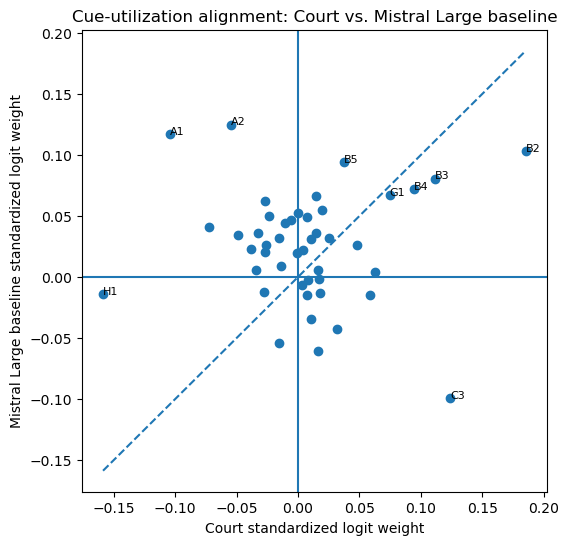

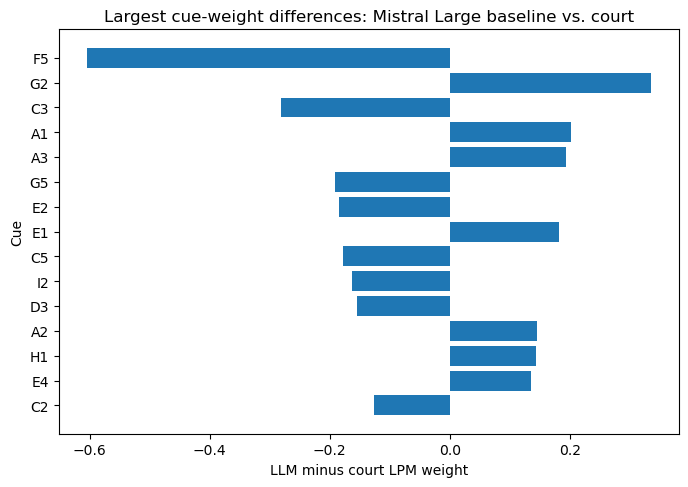

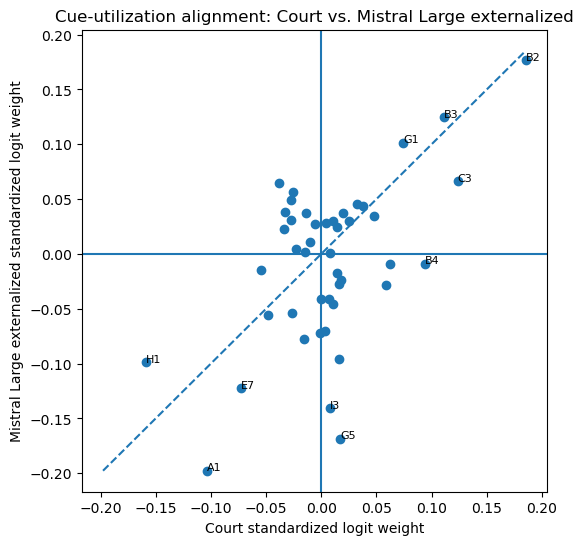

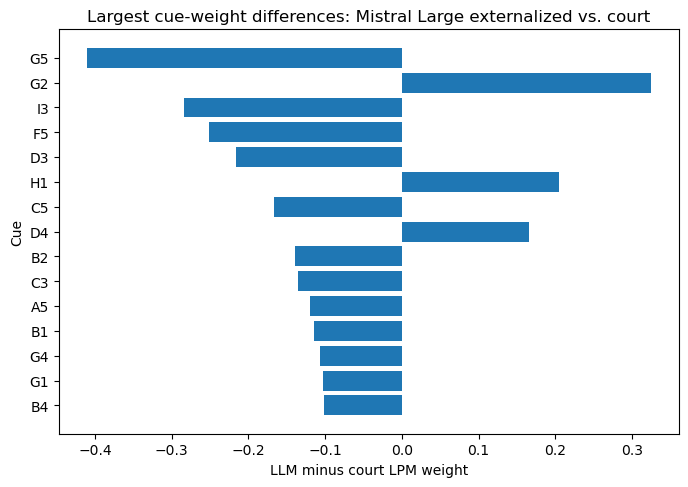

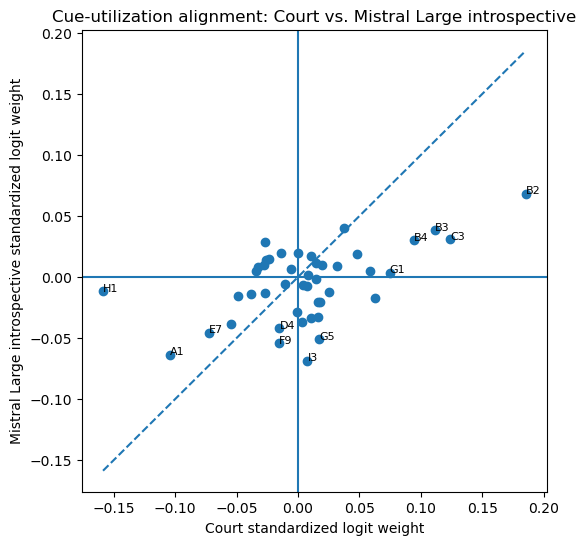

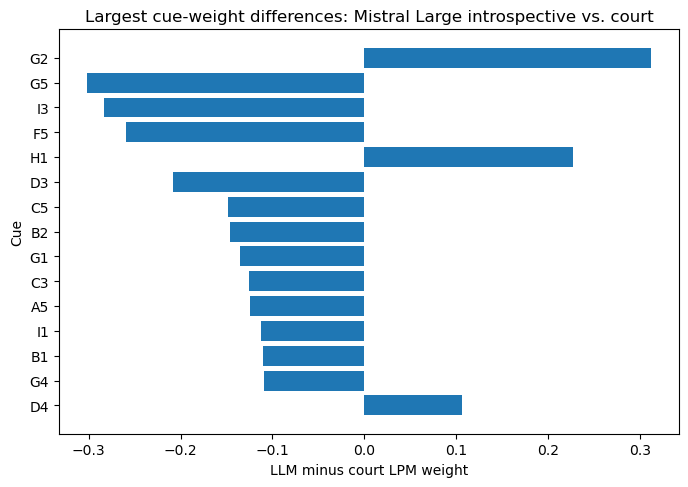

In [27]:
plot_dir = Path('/tmp/cue_utilization_alignment_matplotlib')
plot_dir.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(plot_dir))
os.environ.setdefault('MPLBACKEND', 'Agg')

import matplotlib.pyplot as plt


def plot_weight_alignment(court_coef_df, llm_coef_df, label):
    merged = court_coef_df[['cue', 'coef_std_logit']].merge(
        llm_coef_df[['cue', 'coef_std_logit']],
        on='cue',
        suffixes=('_court', '_llm'),
    )

    plt.figure(figsize=(6, 6))
    plt.scatter(merged['coef_std_logit_court'], merged['coef_std_logit_llm'])
    threshold_court = np.percentile(np.abs(merged['coef_std_logit_court']), 85)
    threshold_llm = np.percentile(np.abs(merged['coef_std_logit_llm']), 85)
    for _, row in merged.iterrows():
        if abs(row['coef_std_logit_court']) >= threshold_court or abs(row['coef_std_logit_llm']) >= threshold_llm:
            plt.text(row['coef_std_logit_court'], row['coef_std_logit_llm'], row['cue'], fontsize=8)
    plt.axhline(0)
    plt.axvline(0)
    mn = min(merged['coef_std_logit_court'].min(), merged['coef_std_logit_llm'].min())
    mx = max(merged['coef_std_logit_court'].max(), merged['coef_std_logit_llm'].max())
    plt.plot([mn, mx], [mn, mx], linestyle='--')
    plt.xlabel('Court standardized logit weight')
    plt.ylabel(f'{label} standardized logit weight')
    plt.title(f'Cue-utilization alignment: Court vs. {label}')
    plt.show()


def plot_top_differences(diff_df, label, n=15):
    top = diff_df.sort_values('abs_llm_minus_court', ascending=False).head(n).iloc[::-1]
    plt.figure(figsize=(8, max(5, n * 0.35)))
    plt.barh(top['cue'], top['llm_minus_court'])
    plt.xlabel('LLM minus court LPM weight')
    plt.ylabel('Cue')
    plt.title(f'Largest cue-weight differences: {label} vs. court')
    plt.show()


for llm_col in LLM_COLS:
    result = all_results[llm_col]
    plot_weight_alignment(court_coef, result['llm_coef'], result['label'])
    plot_top_differences(result['pooled_diff_table'], result['label'], n=min(15, len(CUE_COLS)))

### Prompt-cue shift plots
These panels keep the same court-vs-LLM 2D frame as the earlier scatter plot, but now show how the externalized prompt changed cue weights. Movement toward the dashed diagonal means the cue became more court-aligned.

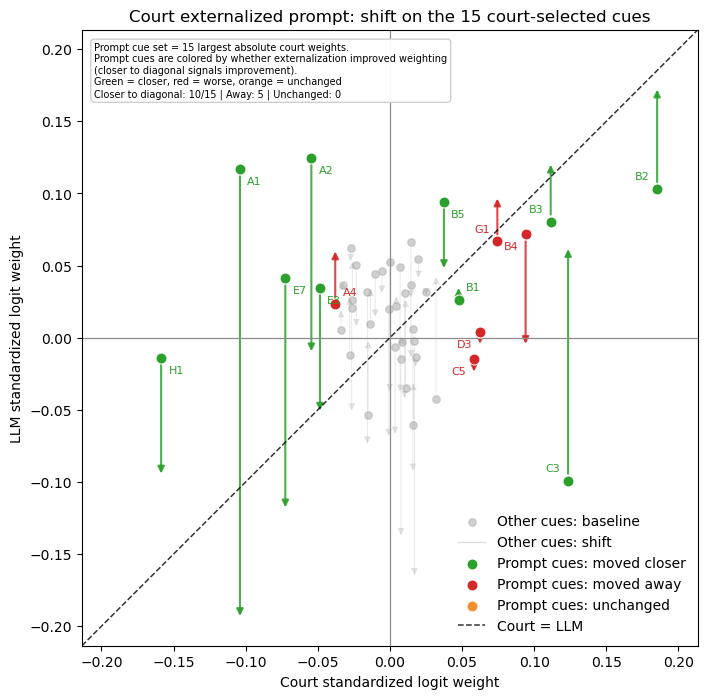

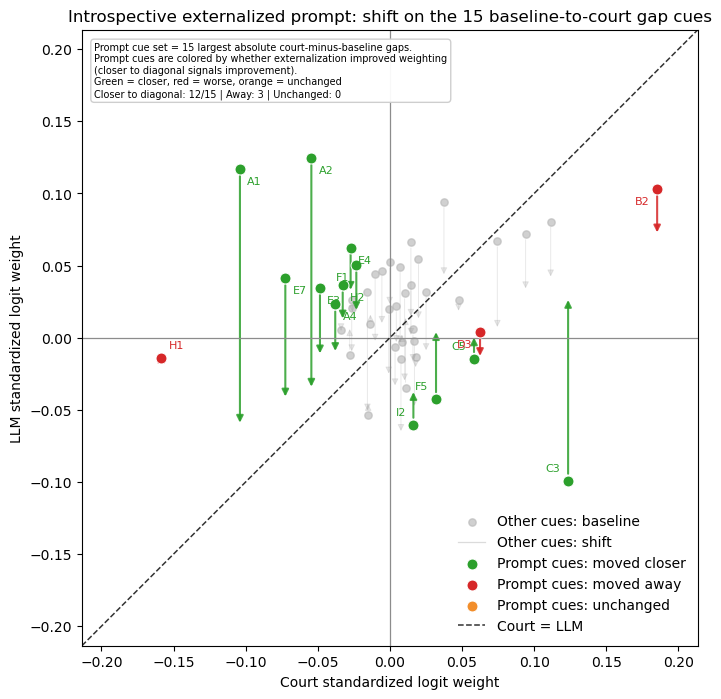

In [28]:
from IPython.display import Markdown, display

BASELINE_SHIFT_COL = 'LLM_baseline_decision_6_violated'
COURT_EXTERNALIZED_SHIFT_COL = 'LLM_externalized_decision_6_violated'
INTROSPECTIVE_SHIFT_COL = 'LLM_introspective_decision_6_violated'
PROMPT_SHIFT_TOP_N = 15
PROMPT_HIGHLIGHT_COLOR = '#f28e2b'
PROMPT_BETTER_COLOR = '#2ca02c'
PROMPT_WORSE_COLOR = '#d62728'
PROMPT_UNCHANGED_COLOR = '#f28e2b'


def _select_top_cues_by_abs_weight(coef_df, n=15):
    return (
        coef_df.assign(abs_weight=coef_df['coef_std_logit'].abs())
        .sort_values(['abs_weight', 'cue'], ascending=[False, True])
        .head(n)['cue']
        .tolist()
    )


def _select_top_cues_by_abs_gap(court_coef_df, baseline_coef_df, n=15):
    merged = (
        court_coef_df[['cue', 'coef_std_logit']]
        .rename(columns={'coef_std_logit': 'court_weight'})
        .merge(
            baseline_coef_df[['cue', 'coef_std_logit']].rename(columns={'coef_std_logit': 'baseline_weight'}),
            on='cue',
            how='inner',
        )
    )
    return (
        merged.assign(abs_gap=(merged['court_weight'] - merged['baseline_weight']).abs())
        .sort_values(['abs_gap', 'cue'], ascending=[False, True])
        .head(n)['cue']
        .tolist()
    )


def _resolve_prompt_cues(explicit_df_name, fallback_selector):
    explicit_df = globals().get(explicit_df_name)
    if isinstance(explicit_df, pd.DataFrame) and 'cue' in explicit_df.columns:
        return explicit_df['cue'].head(PROMPT_SHIFT_TOP_N).tolist()
    return fallback_selector()


def _build_prompt_shift_merged_df(
    court_coef_df,
    baseline_coef_df,
    externalized_coef_df,
    prompt_cues,
):
    merged = (
        court_coef_df[['cue', 'cue_name', 'family', 'coef_std_logit']]
        .rename(columns={'coef_std_logit': 'court_weight'})
        .merge(
            baseline_coef_df[['cue', 'coef_std_logit']].rename(columns={'coef_std_logit': 'baseline_weight'}),
            on='cue',
            how='inner',
        )
        .merge(
            externalized_coef_df[['cue', 'coef_std_logit']].rename(columns={'coef_std_logit': 'externalized_weight'}),
            on='cue',
            how='inner',
        )
        .copy()
    )

    prompt_cues = [cue for cue in prompt_cues if cue in set(merged['cue'])]
    merged['is_prompt_cue'] = merged['cue'].isin(prompt_cues)
    merged['baseline_diag_gap'] = (merged['baseline_weight'] - merged['court_weight']).abs()
    merged['externalized_diag_gap'] = (merged['externalized_weight'] - merged['court_weight']).abs()
    merged['moved_closer'] = merged['externalized_diag_gap'] < merged['baseline_diag_gap']
    merged['moved_away'] = merged['externalized_diag_gap'] > merged['baseline_diag_gap']
    merged['cue_label'] = merged['cue']
    merged['shift_color'] = np.where(
        merged['moved_closer'],
        PROMPT_BETTER_COLOR,
        np.where(merged['moved_away'], PROMPT_WORSE_COLOR, PROMPT_UNCHANGED_COLOR),
    )
    return merged


def _compute_shared_symmetric_axis_limit(*dfs, pad_frac=0.08, min_limit=0.1):
    values = []
    for df in dfs:
        values.extend([
            df['court_weight'].to_numpy(),
            df['baseline_weight'].to_numpy(),
            df['externalized_weight'].to_numpy(),
        ])

    all_values = np.concatenate(values)
    finite_values = all_values[np.isfinite(all_values)]

    if finite_values.size == 0:
        return min_limit

    max_abs = float(np.max(np.abs(finite_values)))
    limit = max_abs * (1 + pad_frac)
    return max(limit, min_limit)


def plot_prompt_shift_alignment(
    court_coef_df,
    baseline_coef_df,
    externalized_coef_df,
    prompt_cues,
    title,
    selection_note,
    axis_limit=None,
    highlight_color=PROMPT_HIGHLIGHT_COLOR,
):
    merged = _build_prompt_shift_merged_df(
        court_coef_df,
        baseline_coef_df,
        externalized_coef_df,
        prompt_cues,
    )

    prompt_df = merged.loc[merged['is_prompt_cue']].copy()
    other_df = merged.loc[~merged['is_prompt_cue']].copy()

    if prompt_df.empty:
        raise ValueError(f'No prompt cues available to plot for: {title}')

    if axis_limit is None:
        axis_limit = _compute_shared_symmetric_axis_limit(merged)

    axis_low = -axis_limit
    axis_high = axis_limit
    text_dx = 0.012 * (axis_high - axis_low)
    text_dy = 0.012 * (axis_high - axis_low)

    fig, ax = plt.subplots(figsize=(8, 8))

    ax.scatter(
        other_df['court_weight'],
        other_df['baseline_weight'],
        color='0.72',
        alpha=0.65,
        s=28,
        label='Other cues: baseline',
    )
    for _, row in other_df.iterrows():
        ax.annotate(
            '',
            xy=(row['court_weight'], row['externalized_weight']),
            xytext=(row['court_weight'], row['baseline_weight']),
            arrowprops=dict(
                arrowstyle='-|>',
                color='0.6',
                lw=0.7,
                alpha=0.22,
                shrinkA=4,
                shrinkB=4,
            ),
            zorder=1,
        )

    ax.plot([], [], color='0.6', lw=0.9, alpha=0.35, label='Other cues: shift')

    for _, row in prompt_df.iterrows():
        ax.scatter(
            row['court_weight'],
            row['baseline_weight'],
            color=row['shift_color'],
            edgecolor='white',
            linewidth=0.7,
            s=62,
            zorder=3,
        )
        ax.annotate(
            '',
            xy=(row['court_weight'], row['externalized_weight']),
            xytext=(row['court_weight'], row['baseline_weight']),
            arrowprops=dict(
                arrowstyle='-|>',
                color=row['shift_color'],
                lw=1.5,
                alpha=0.85,
                shrinkA=5,
                shrinkB=5,
            ),
            zorder=2,
        )

    ax.scatter([], [], color=PROMPT_BETTER_COLOR, edgecolor='white', linewidth=0.7, s=62, label='Prompt cues: moved closer')
    ax.scatter([], [], color=PROMPT_WORSE_COLOR, edgecolor='white', linewidth=0.7, s=62, label='Prompt cues: moved away')
    ax.scatter([], [], color=PROMPT_UNCHANGED_COLOR, edgecolor='white', linewidth=0.7, s=62, label='Prompt cues: unchanged')

    for _, row in prompt_df.sort_values(['moved_closer', 'baseline_diag_gap'], ascending=[False, False]).iterrows():
        x = float(row['court_weight'])
        y = float(row['baseline_weight'])
        ha = 'left' if x <= np.median(prompt_df['court_weight']) else 'right'
        x_text = x + text_dx if ha == 'left' else x - text_dx
        moved_up = float(row['externalized_weight']) >= float(row['baseline_weight'])
        y_text = y + text_dy if moved_up else y - text_dy
        va = 'bottom' if moved_up else 'top'
        ax.text(
            x_text,
            y_text,
            row['cue_label'],
            color=row['shift_color'],
            fontsize=8,
            ha=ha,
            va=va,
            zorder=5,
        )

    ax.axhline(0, color='0.55', linewidth=0.9)
    ax.axvline(0, color='0.55', linewidth=0.9)
    ax.plot(
        [axis_low, axis_high],
        [axis_low, axis_high],
        linestyle='--',
        color='black',
        linewidth=1.1,
        alpha=0.8,
        label='Court = LLM',
    )

    ax.set_xlim(axis_low, axis_high)
    ax.set_ylim(axis_low, axis_high)
    ax.set_aspect('equal', adjustable='box')

    ax.set_xlabel('Court standardized logit weight')
    ax.set_ylabel('LLM standardized logit weight')
    ax.set_title(title)

    moved_closer_n = int(prompt_df['moved_closer'].sum())
    moved_away_n = int((prompt_df['externalized_diag_gap'] > prompt_df['baseline_diag_gap']).sum())
    unchanged_n = int(len(prompt_df) - moved_closer_n - moved_away_n)
    summary = (
        f'{selection_note}\n'
        'Prompt cues are colored by whether externalization improved weighting\n'
        '(closer to diagonal signals improvement).\n'
        'Green = closer, red = worse, orange = unchanged\n'
        f'Closer to diagonal: {moved_closer_n}/{len(prompt_df)} | Away: {moved_away_n} | Unchanged: {unchanged_n}'
    )
    ax.text(
        0.02,
        0.98,
        summary,
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=7,
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='0.8', alpha=0.95),
    )
    ax.legend(loc='lower right', frameon=False)
    plt.show()


court_prompt_shift_cues = _resolve_prompt_cues(
    'COURT_PROMPT_RUBRIC_DF',
    lambda: _select_top_cues_by_abs_weight(court_coef, n=PROMPT_SHIFT_TOP_N),
)
introspective_prompt_shift_cues = _resolve_prompt_cues(
    'BASELINE_GAP_PROMPT_DF',
    lambda: _select_top_cues_by_abs_gap(
        court_coef,
        all_results[BASELINE_SHIFT_COL]['llm_coef'],
        n=PROMPT_SHIFT_TOP_N,
    ),
)

display(Markdown(
    '### Prompt-cue shift plots\n'
    'These panels keep the same court-vs-LLM 2D frame as the earlier scatter plot, '
    'but now show how the externalized prompt changed cue weights. '
    'Movement toward the dashed diagonal means the cue became more court-aligned.'
))

# Build both merged frames first, then compute one shared symmetric axis limit
merged_court_externalized = _build_prompt_shift_merged_df(
    court_coef,
    all_results[BASELINE_SHIFT_COL]['llm_coef'],
    all_results[COURT_EXTERNALIZED_SHIFT_COL]['llm_coef'],
    court_prompt_shift_cues,
)

merged_introspective_externalized = _build_prompt_shift_merged_df(
    court_coef,
    all_results[BASELINE_SHIFT_COL]['llm_coef'],
    all_results[INTROSPECTIVE_SHIFT_COL]['llm_coef'],
    introspective_prompt_shift_cues,
)

shared_axis_limit = _compute_shared_symmetric_axis_limit(
    merged_court_externalized,
    merged_introspective_externalized,
)

plot_prompt_shift_alignment(
    court_coef,
    all_results[BASELINE_SHIFT_COL]['llm_coef'],
    all_results[COURT_EXTERNALIZED_SHIFT_COL]['llm_coef'],
    court_prompt_shift_cues,
    title='Court externalized prompt: shift on the 15 court-selected cues',
    selection_note='Prompt cue set = 15 largest absolute court weights.',
    axis_limit=shared_axis_limit,
)

plot_prompt_shift_alignment(
    court_coef,
    all_results[BASELINE_SHIFT_COL]['llm_coef'],
    all_results[INTROSPECTIVE_SHIFT_COL]['llm_coef'],
    introspective_prompt_shift_cues,
    title='Introspective externalized prompt: shift on the 15 baseline-to-court gap cues',
    selection_note='Prompt cue set = 15 largest absolute court-minus-baseline gaps.',
    axis_limit=shared_axis_limit,
)

## 7. Optional bootstrap for coefficient-alignment uncertainty

This is slower, but useful if you want interval estimates for policy similarity.

### What it does

For each bootstrap resample of cases:

- refit the court ridge model
- refit each LLM ridge model
- recompute coefficient-alignment metrics

### Suggested reporting

Report the median and percentile interval for:

- coefficient Pearson `r`
- cosine similarity
- sign agreement

### What the next cell runs

This cell runs a **bootstrap uncertainty analysis** for the cue-alignment metrics.

Why this cell matters:
- the main alignment metrics are point estimates from one sample
- the bootstrap shows how stable those metrics are under repeated resampling of cases
- this is mainly useful for appendices, robustness checks, or interval reporting in a paper

In [29]:
RUN_BOOTSTRAP = True
N_BOOT = 500

if RUN_BOOTSTRAP:
    rng = np.random.default_rng(RANDOM_STATE)
    boot_rows = []
    base = analysis_df[[CASE_ID_COL, COURT_COL] + LLM_COLS + CUE_COLS].copy()

    for b in range(N_BOOT):
        sample_idx = rng.integers(0, len(base), len(base))
        boot = base.iloc[sample_idx].reset_index(drop=True)

        y_c = boot[COURT_COL].astype(int)
        if not has_two_classes(y_c):
            continue

        Xb = boot[CUE_COLS]
        _, _, court_coef_b = fit_final_ridge_and_extract_weights(Xb, y_c, CUE_COLS)

        for llm_col in LLM_COLS:
            y_l = boot[llm_col].astype(int)
            if not has_two_classes(y_l):
                continue
            _, _, llm_coef_b = fit_final_ridge_and_extract_weights(Xb, y_l, CUE_COLS)
            align_b = align_weights(court_coef_b, llm_coef_b, top_k=min(10, len(CUE_COLS)))
            boot_rows.append({
                'bootstrap': b,
                'llm_col': llm_col,
                'llm_label': LLM_LABELS.get(llm_col, llm_col),
                'coef_pearson_r': align_b['coef_pearson_r'],
                'coef_cosine_similarity': align_b['coef_cosine_similarity'],
                'sign_agreement': align_b['sign_agreement'],
            })

    if not boot_rows:
        print('Bootstrap produced no usable resamples. Try a larger sample or fewer restrictions.')
    else:
        boot_df = pd.DataFrame(boot_rows)
        ci_rows = []
        for llm_col, group in boot_df.groupby('llm_col'):
            row = {'llm_col': llm_col, 'llm_label': group['llm_label'].iloc[0]}
            for metric in ['coef_pearson_r', 'coef_cosine_similarity', 'sign_agreement']:
                vals = group[metric].dropna().to_numpy()
                if len(vals) == 0:
                    row[f'{metric}_median'] = np.nan
                    row[f'{metric}_lo'] = np.nan
                    row[f'{metric}_hi'] = np.nan
                else:
                    row[f'{metric}_median'] = np.median(vals)
                    row[f'{metric}_lo'] = np.percentile(vals, 2.5)
                    row[f'{metric}_hi'] = np.percentile(vals, 97.5)
            ci_rows.append(row)

        boot_summary = pd.DataFrame(ci_rows)
        display(boot_summary)


KeyboardInterrupt: 

## 7b. Is the externalized prompt significantly more court-aligned than baseline?

### What the next cell runs

This cell runs the notebook's **direct baseline-vs-externalized significance test** for cue-utilization alignment.

Why this is the right test here:
- both prompt setups are evaluated on the **same cases** and the **same cue set**
- the inferential target is the **change in similarity to the court's cue-weight vector**, not just whether each setup differs from the court in isolation
- a **paired case bootstrap** respects that dependence by recomputing both setups on the same resampled cases and testing whether `externalized - baseline` is above zero

Primary test:
- **one-sided paired bootstrap test on the change in coefficient cosine similarity** to the court

Secondary robustness metrics:
- coefficient Pearson correlation
- sign agreement


In [ ]:
## court externalized knowledge
BASELINE_COL = 'LLM_baseline_decision_6_violated'
EXTERNALIZED_COL = 'LLM_externalized_decision_6_violated'
PRIMARY_ALIGNMENT_METRIC = 'coef_cosine_similarity'
SECONDARY_ALIGNMENT_METRICS = ['coef_pearson_r', 'sign_agreement']
ALL_ALIGNMENT_METRICS = [PRIMARY_ALIGNMENT_METRIC] + SECONDARY_ALIGNMENT_METRICS

required_cols = {BASELINE_COL, EXTERNALIZED_COL}
missing = sorted(required_cols - set(LLM_COLS))
if missing:
    raise ValueError(f'Missing expected LLM columns for paired comparison: {missing}')

if 'boot_df' not in globals() or not isinstance(boot_df, pd.DataFrame) or boot_df.empty:
    raise RuntimeError('This comparison uses the paired bootstrap draws from Section 7. Run the bootstrap cell first.')

summary_lookup = summary_df.set_index('llm_col')
comparison_rows = []
paired_boot_tables = {}

for metric in ALL_ALIGNMENT_METRICS:
    wide = (
        boot_df
        .pivot_table(index='bootstrap', columns='llm_col', values=metric, aggfunc='first')
        [[BASELINE_COL, EXTERNALIZED_COL]]
        .dropna()
        .copy()
    )
    if wide.empty:
        comparison_rows.append({
            'metric': metric,
            'baseline_point_estimate': np.nan,
            'externalized_point_estimate': np.nan,
            'delta_externalized_minus_baseline': np.nan,
            'bootstrap_replicates': 0,
            'delta_median': np.nan,
            'delta_ci_low_95': np.nan,
            'delta_ci_high_95': np.nan,
            'one_sided_p_externalized_better': np.nan,
            'primary_test': metric == PRIMARY_ALIGNMENT_METRIC,
        })
        continue

    wide['delta_externalized_minus_baseline'] = wide[EXTERNALIZED_COL] - wide[BASELINE_COL]
    delta = wide['delta_externalized_minus_baseline'].to_numpy()
    paired_boot_tables[metric] = wide.reset_index()

    baseline_point = float(summary_lookup.loc[BASELINE_COL, metric])
    externalized_point = float(summary_lookup.loc[EXTERNALIZED_COL, metric])
    observed_delta = externalized_point - baseline_point

    comparison_rows.append({
        'metric': metric,
        'baseline_point_estimate': baseline_point,
        'externalized_point_estimate': externalized_point,
        'delta_externalized_minus_baseline': observed_delta,
        'bootstrap_replicates': int(len(delta)),
        'delta_median': float(np.median(delta)),
        'delta_ci_low_95': float(np.percentile(delta, 2.5)),
        'delta_ci_high_95': float(np.percentile(delta, 97.5)),
        'one_sided_p_externalized_better': float((np.sum(delta <= 0) + 1) / (len(delta) + 1)),
        'primary_test': metric == PRIMARY_ALIGNMENT_METRIC,
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df['metric_label'] = comparison_df['metric'].map({
    'coef_cosine_similarity': 'Coefficient cosine similarity',
    'coef_pearson_r': 'Coefficient Pearson correlation',
    'sign_agreement': 'Cue sign agreement',
})
comparison_df = comparison_df[[
    'metric_label',
    'metric',
    'primary_test',
    'baseline_point_estimate',
    'externalized_point_estimate',
    'delta_externalized_minus_baseline',
    'delta_median',
    'delta_ci_low_95',
    'delta_ci_high_95',
    'one_sided_p_externalized_better',
    'bootstrap_replicates',
]].sort_values(['primary_test', 'metric_label'], ascending=[False, True]).reset_index(drop=True)

display(Markdown('### Direct test of whether the externalized prompt is more court-aligned than baseline'))
display(comparison_df)

primary_row = comparison_df.loc[comparison_df['metric'] == PRIMARY_ALIGNMENT_METRIC].iloc[0]
if pd.isna(primary_row['one_sided_p_externalized_better']):
    interpretation = (
        'Primary test unavailable because the paired bootstrap did not produce usable draws '
        'for the prespecified alignment metric.'
    )
elif primary_row['delta_ci_low_95'] > 0:
    interpretation = (
        'The externalized prompt is significantly more court-aligned than baseline on the '
        'prespecified primary metric: coefficient cosine similarity. '
        f"Observed delta = {primary_row['delta_externalized_minus_baseline']:.4f}, "
        f"95% bootstrap CI = [{primary_row['delta_ci_low_95']:.4f}, {primary_row['delta_ci_high_95']:.4f}], "
        f"one-sided p = {primary_row['one_sided_p_externalized_better']:.4f}."
    )
elif primary_row['delta_externalized_minus_baseline'] > 0:
    interpretation = (
        'The externalized prompt improves court-alignment on the prespecified primary metric, '
        'but the improvement is not statistically distinguishable from zero at the 5% level. '
        f"Observed delta = {primary_row['delta_externalized_minus_baseline']:.4f}, "
        f"95% bootstrap CI = [{primary_row['delta_ci_low_95']:.4f}, {primary_row['delta_ci_high_95']:.4f}], "
        f"one-sided p = {primary_row['one_sided_p_externalized_better']:.4f}."
    )
else:
    interpretation = (
        'The externalized prompt is not more court-aligned than baseline on the prespecified '
        'primary metric. '
        f"Observed delta = {primary_row['delta_externalized_minus_baseline']:.4f}, "
        f"95% bootstrap CI = [{primary_row['delta_ci_low_95']:.4f}, {primary_row['delta_ci_high_95']:.4f}], "
        f"one-sided p = {primary_row['one_sided_p_externalized_better']:.4f}."
    )

display(Markdown('#### Interpretation'))
display(Markdown(interpretation))

if PRIMARY_ALIGNMENT_METRIC in paired_boot_tables:
    display(Markdown('#### First bootstrap draws for the primary metric'))
    display(paired_boot_tables[PRIMARY_ALIGNMENT_METRIC].head(10))



### Direct test of whether the externalized prompt is more court-aligned than baseline

,metric_label,metric,primary_test,baseline_point_estimate,externalized_point_estimate,delta_externalized_minus_baseline,delta_median,delta_ci_low_95,delta_ci_high_95,one_sided_p_externalized_better,bootstrap_replicates
0,Coefficient cosine similarity,coef_cosine_similarity,True,-0.082059,0.637234,0.719293,0.449497,0.200025,0.682933,0.004975,200
1,Coefficient Pearson correlation,coef_pearson_r,False,-0.184800,0.634676,0.819476,0.499659,0.231624,0.773666,0.004975,200
2,Cue sign agreement,sign_agreement,False,0.488889,0.533333,0.044444,0.044444,-0.133333,0.177778,0.303483,200


#### Interpretation

The externalized prompt is significantly more court-aligned than baseline on the prespecified primary metric: coefficient cosine similarity. Observed delta = 0.7193, 95% bootstrap CI = [0.2000, 0.6829], one-sided p = 0.0050.

#### First bootstrap draws for the primary metric

llm_col,bootstrap,LLM_baseline_decision_6_violated,LLM_externalized_decision_6_violated,delta_externalized_minus_baseline
0,0,-0.057493,0.443422,0.500915
1,1,0.113739,0.527804,0.414066
2,2,-0.046565,0.540681,0.587246
3,3,0.049100,0.453506,0.404405
4,4,0.032379,0.457017,0.424638
5,5,-0.098563,0.501411,0.599974
6,6,-0.003153,0.305755,0.308908
7,7,0.032870,0.346650,0.313780
8,8,-0.005479,0.429951,0.435430
9,9,0.085867,0.412999,0.327131


In [ ]:
## For introspective externalization:
BASELINE_COL = 'LLM_baseline_decision_6_violated'
EXTERNALIZED_COL = 'LLM_introspective_decision_6_violated'
PRIMARY_ALIGNMENT_METRIC = 'coef_cosine_similarity'
SECONDARY_ALIGNMENT_METRICS = ['coef_pearson_r', 'sign_agreement']
ALL_ALIGNMENT_METRICS = [PRIMARY_ALIGNMENT_METRIC] + SECONDARY_ALIGNMENT_METRICS

required_cols = {BASELINE_COL, EXTERNALIZED_COL}
missing = sorted(required_cols - set(LLM_COLS))
if missing:
    raise ValueError(f'Missing expected LLM columns for paired comparison: {missing}')

if 'boot_df' not in globals() or not isinstance(boot_df, pd.DataFrame) or boot_df.empty:
    raise RuntimeError('This comparison uses the paired bootstrap draws from Section 7. Run the bootstrap cell first.')

summary_lookup = summary_df.set_index('llm_col')
comparison_rows = []
paired_boot_tables = {}

for metric in ALL_ALIGNMENT_METRICS:
    wide = (
        boot_df
        .pivot_table(index='bootstrap', columns='llm_col', values=metric, aggfunc='first')
        [[BASELINE_COL, EXTERNALIZED_COL]]
        .dropna()
        .copy()
    )
    if wide.empty:
        comparison_rows.append({
            'metric': metric,
            'baseline_point_estimate': np.nan,
            'externalized_point_estimate': np.nan,
            'delta_externalized_minus_baseline': np.nan,
            'bootstrap_replicates': 0,
            'delta_median': np.nan,
            'delta_ci_low_95': np.nan,
            'delta_ci_high_95': np.nan,
            'one_sided_p_externalized_better': np.nan,
            'primary_test': metric == PRIMARY_ALIGNMENT_METRIC,
        })
        continue

    wide['delta_externalized_minus_baseline'] = wide[EXTERNALIZED_COL] - wide[BASELINE_COL]
    delta = wide['delta_externalized_minus_baseline'].to_numpy()
    paired_boot_tables[metric] = wide.reset_index()

    baseline_point = float(summary_lookup.loc[BASELINE_COL, metric])
    externalized_point = float(summary_lookup.loc[EXTERNALIZED_COL, metric])
    observed_delta = externalized_point - baseline_point

    comparison_rows.append({
        'metric': metric,
        'baseline_point_estimate': baseline_point,
        'externalized_point_estimate': externalized_point,
        'delta_externalized_minus_baseline': observed_delta,
        'bootstrap_replicates': int(len(delta)),
        'delta_median': float(np.median(delta)),
        'delta_ci_low_95': float(np.percentile(delta, 2.5)),
        'delta_ci_high_95': float(np.percentile(delta, 97.5)),
        'one_sided_p_externalized_better': float((np.sum(delta <= 0) + 1) / (len(delta) + 1)),
        'primary_test': metric == PRIMARY_ALIGNMENT_METRIC,
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df['metric_label'] = comparison_df['metric'].map({
    'coef_cosine_similarity': 'Coefficient cosine similarity',
    'coef_pearson_r': 'Coefficient Pearson correlation',
    'sign_agreement': 'Cue sign agreement',
})
comparison_df = comparison_df[[
    'metric_label',
    'metric',
    'primary_test',
    'baseline_point_estimate',
    'externalized_point_estimate',
    'delta_externalized_minus_baseline',
    'delta_median',
    'delta_ci_low_95',
    'delta_ci_high_95',
    'one_sided_p_externalized_better',
    'bootstrap_replicates',
]].sort_values(['primary_test', 'metric_label'], ascending=[False, True]).reset_index(drop=True)

display(Markdown('### Direct test of whether the externalized prompt is more court-aligned than baseline'))
display(comparison_df)

primary_row = comparison_df.loc[comparison_df['metric'] == PRIMARY_ALIGNMENT_METRIC].iloc[0]
if pd.isna(primary_row['one_sided_p_externalized_better']):
    interpretation = (
        'Primary test unavailable because the paired bootstrap did not produce usable draws '
        'for the prespecified alignment metric.'
    )
elif primary_row['delta_ci_low_95'] > 0:
    interpretation = (
        'The externalized prompt is significantly more court-aligned than baseline on the '
        'prespecified primary metric: coefficient cosine similarity. '
        f"Observed delta = {primary_row['delta_externalized_minus_baseline']:.4f}, "
        f"95% bootstrap CI = [{primary_row['delta_ci_low_95']:.4f}, {primary_row['delta_ci_high_95']:.4f}], "
        f"one-sided p = {primary_row['one_sided_p_externalized_better']:.4f}."
    )
elif primary_row['delta_externalized_minus_baseline'] > 0:
    interpretation = (
        'The externalized prompt improves court-alignment on the prespecified primary metric, '
        'but the improvement is not statistically distinguishable from zero at the 5% level. '
        f"Observed delta = {primary_row['delta_externalized_minus_baseline']:.4f}, "
        f"95% bootstrap CI = [{primary_row['delta_ci_low_95']:.4f}, {primary_row['delta_ci_high_95']:.4f}], "
        f"one-sided p = {primary_row['one_sided_p_externalized_better']:.4f}."
    )
else:
    interpretation = (
        'The externalized prompt is not more court-aligned than baseline on the prespecified '
        'primary metric. '
        f"Observed delta = {primary_row['delta_externalized_minus_baseline']:.4f}, "
        f"95% bootstrap CI = [{primary_row['delta_ci_low_95']:.4f}, {primary_row['delta_ci_high_95']:.4f}], "
        f"one-sided p = {primary_row['one_sided_p_externalized_better']:.4f}."
    )

display(Markdown('#### Interpretation'))
display(Markdown(interpretation))

if PRIMARY_ALIGNMENT_METRIC in paired_boot_tables:
    display(Markdown('#### First bootstrap draws for the primary metric'))
    display(paired_boot_tables[PRIMARY_ALIGNMENT_METRIC].head(10))



### Direct test of whether the externalized prompt is more court-aligned than baseline

,metric_label,metric,primary_test,baseline_point_estimate,externalized_point_estimate,delta_externalized_minus_baseline,delta_median,delta_ci_low_95,delta_ci_high_95,one_sided_p_externalized_better,bootstrap_replicates
0,Coefficient cosine similarity,coef_cosine_similarity,True,-0.082059,0.711073,0.793132,0.518079,0.247524,0.713083,0.004975,200
1,Coefficient Pearson correlation,coef_pearson_r,False,-0.184800,0.716258,0.901058,0.577888,0.285640,0.808344,0.004975,200
2,Cue sign agreement,sign_agreement,False,0.488889,0.577778,0.088889,0.111111,-0.067222,0.244444,0.124378,200


#### Interpretation

The externalized prompt is significantly more court-aligned than baseline on the prespecified primary metric: coefficient cosine similarity. Observed delta = 0.7931, 95% bootstrap CI = [0.2475, 0.7131], one-sided p = 0.0050.

#### First bootstrap draws for the primary metric

llm_col,bootstrap,LLM_baseline_decision_6_violated,LLM_introspective_decision_6_violated,delta_externalized_minus_baseline
0,0,-0.057493,0.474020,0.531513
1,1,0.113739,0.617958,0.504219
2,2,-0.046565,0.585606,0.632170
3,3,0.049100,0.606520,0.557420
4,4,0.032379,0.514420,0.482041
5,5,-0.098563,0.598361,0.696924
6,6,-0.003153,0.501047,0.504200
7,7,0.032870,0.618766,0.585895
8,8,-0.005479,0.574966,0.580445
9,9,0.085867,0.496189,0.410322


## 7c. Did alignment improve specifically on the cues explicitly provided in the prompt?

### What the next cell runs

This cell tests whether the externalized prompt improved court-alignment **on the subset of cues that were explicitly named in the prompt text**.

Why this analysis matters:
- the overall alignment test asks whether the full cue-utilization profile moved closer to the court
- this targeted test asks whether the prompt helped specifically on the cues the model was directly told about
- the coefficient vectors are still estimated from the **full cue set**; the comparison then restricts the alignment metrics to the explicit-prompt cue subset

Primary test:
- **one-sided paired bootstrap test on the change in coefficient cosine similarity, restricted to the explicit-prompt cues**

Secondary robustness metrics:
- coefficient Pearson correlation on the explicit-prompt cues
- sign agreement on the explicit-prompt cues


In [ ]:
## court weighting externalization explicit-prompt-cue subset analysis
BASELINE_COL = 'LLM_baseline_decision_6_violated'
EXTERNALIZED_COL = 'LLM_externalized_decision_6_violated'

PROMPT_EXPLICIT_CUES = ['B2',
 'H1',
 'C3',
 'B3',
 'A1',
 'B4',
 'G1',
 'E7',
 'D3',
 'C5',
 'A2',
 'E3',
 'B1',
 'A4',
 'B5']

prompt_explicit_cues_available = [cue for cue in PROMPT_EXPLICIT_CUES if cue in CUE_COLS]
prompt_explicit_cues_missing = [cue for cue in PROMPT_EXPLICIT_CUES if cue not in CUE_COLS]

if len(prompt_explicit_cues_available) < 3:
    raise ValueError(
        'Fewer than 3 explicit prompt cues are available after cue screening; '
        'cannot run subset alignment analysis.'
    )

prompt_cue_lookup = pd.DataFrame({
    'cue': prompt_explicit_cues_available,
    'cue_name': [cue_name_map.get(c, c) for c in prompt_explicit_cues_available],
    'family': [cue_family_map.get(c, '') for c in prompt_explicit_cues_available],
})

display(Markdown('### Explicitly provided prompt cues used in this subset analysis'))
display(prompt_cue_lookup)
if prompt_explicit_cues_missing:
    display(Markdown(
        '#### Note on unavailable prompt cues\n'
        'These explicit-prompt cues were not available after notebook cue screening: '
        + ', '.join(prompt_explicit_cues_missing)
    ))

def align_on_subset(court_coef_df, llm_coef_df, cue_subset):
    court_subset = court_coef_df[court_coef_df['cue'].isin(cue_subset)].copy()
    llm_subset = llm_coef_df[llm_coef_df['cue'].isin(cue_subset)].copy()
    return align_weights(court_subset, llm_subset, top_k=min(10, len(cue_subset)))


prompt_subset_rows = []
for llm_col in [BASELINE_COL, EXTERNALIZED_COL]:
    subset_align = align_on_subset(court_coef, all_results[llm_col]['llm_coef'], prompt_explicit_cues_available)
    prompt_subset_rows.append({
        'llm_col': llm_col,
        'llm_label': LLM_LABELS.get(llm_col, llm_col),
        'coef_cosine_similarity': subset_align['coef_cosine_similarity'],
        'coef_pearson_r': subset_align['coef_pearson_r'],
        'sign_agreement': subset_align['sign_agreement'],
        'topk_overlap': subset_align['topk_overlap'],
        'n_prompt_cues_tested': len(prompt_explicit_cues_available),
    })

prompt_subset_alignment_df = pd.DataFrame(prompt_subset_rows)
display(Markdown('### Point estimates for alignment on explicit-prompt cues only'))
display(prompt_subset_alignment_df)

PROMPT_CUE_PRIMARY_METRIC = 'coef_cosine_similarity'
PROMPT_CUE_SECONDARY_METRICS = ['coef_pearson_r', 'sign_agreement']
PROMPT_CUE_ALL_METRICS = [PROMPT_CUE_PRIMARY_METRIC] + PROMPT_CUE_SECONDARY_METRICS
PROMPT_CUE_BOOTSTRAPS = N_BOOT if 'N_BOOT' in globals() else 200

rng = np.random.default_rng(RANDOM_STATE)
prompt_subset_boot_rows = []
base = analysis_df[[CASE_ID_COL, COURT_COL, BASELINE_COL, EXTERNALIZED_COL] + CUE_COLS].copy()

for b in range(PROMPT_CUE_BOOTSTRAPS):
    sample_idx = rng.integers(0, len(base), len(base))
    boot = base.iloc[sample_idx].reset_index(drop=True)

    y_c = boot[COURT_COL].astype(int)
    if not has_two_classes(y_c):
        continue

    Xb = boot[CUE_COLS]
    _, _, court_coef_b = fit_final_ridge_and_extract_weights(Xb, y_c, CUE_COLS)

    for llm_col in [BASELINE_COL, EXTERNALIZED_COL]:
        y_l = boot[llm_col].astype(int)
        if not has_two_classes(y_l):
            continue
        _, _, llm_coef_b = fit_final_ridge_and_extract_weights(Xb, y_l, CUE_COLS)
        subset_align_b = align_on_subset(court_coef_b, llm_coef_b, prompt_explicit_cues_available)
        prompt_subset_boot_rows.append({
            'bootstrap': b,
            'llm_col': llm_col,
            'llm_label': LLM_LABELS.get(llm_col, llm_col),
            'coef_cosine_similarity': subset_align_b['coef_cosine_similarity'],
            'coef_pearson_r': subset_align_b['coef_pearson_r'],
            'sign_agreement': subset_align_b['sign_agreement'],
        })

if not prompt_subset_boot_rows:
    raise RuntimeError('Prompt-cue bootstrap produced no usable resamples.')

prompt_subset_boot_df = pd.DataFrame(prompt_subset_boot_rows)
prompt_subset_lookup = prompt_subset_alignment_df.set_index('llm_col')
prompt_subset_comparison_rows = []
prompt_subset_paired_tables = {}

for metric in PROMPT_CUE_ALL_METRICS:
    wide = (
        prompt_subset_boot_df
        .pivot_table(index='bootstrap', columns='llm_col', values=metric, aggfunc='first')
        [[BASELINE_COL, EXTERNALIZED_COL]]
        .dropna()
        .copy()
    )
    if wide.empty:
        prompt_subset_comparison_rows.append({
            'metric': metric,
            'baseline_point_estimate': np.nan,
            'externalized_point_estimate': np.nan,
            'delta_externalized_minus_baseline': np.nan,
            'delta_median': np.nan,
            'delta_ci_low_95': np.nan,
            'delta_ci_high_95': np.nan,
            'one_sided_p_externalized_better': np.nan,
            'bootstrap_replicates': 0,
            'primary_test': metric == PROMPT_CUE_PRIMARY_METRIC,
        })
        continue

    wide['delta_externalized_minus_baseline'] = wide[EXTERNALIZED_COL] - wide[BASELINE_COL]
    delta = wide['delta_externalized_minus_baseline'].to_numpy()
    prompt_subset_paired_tables[metric] = wide.reset_index()

    baseline_point = float(prompt_subset_lookup.loc[BASELINE_COL, metric])
    externalized_point = float(prompt_subset_lookup.loc[EXTERNALIZED_COL, metric])
    observed_delta = externalized_point - baseline_point

    prompt_subset_comparison_rows.append({
        'metric': metric,
        'baseline_point_estimate': baseline_point,
        'externalized_point_estimate': externalized_point,
        'delta_externalized_minus_baseline': observed_delta,
        'delta_median': float(np.median(delta)),
        'delta_ci_low_95': float(np.percentile(delta, 2.5)),
        'delta_ci_high_95': float(np.percentile(delta, 97.5)),
        'one_sided_p_externalized_better': float((np.sum(delta <= 0) + 1) / (len(delta) + 1)),
        'bootstrap_replicates': int(len(delta)),
        'primary_test': metric == PROMPT_CUE_PRIMARY_METRIC,
    })

prompt_subset_comparison_df = pd.DataFrame(prompt_subset_comparison_rows)
prompt_subset_comparison_df['metric_label'] = prompt_subset_comparison_df['metric'].map({
    'coef_cosine_similarity': 'Coefficient cosine similarity on explicit-prompt cues',
    'coef_pearson_r': 'Coefficient Pearson correlation on explicit-prompt cues',
    'sign_agreement': 'Cue sign agreement on explicit-prompt cues',
})
prompt_subset_comparison_df = prompt_subset_comparison_df[[
    'metric_label',
    'metric',
    'primary_test',
    'baseline_point_estimate',
    'externalized_point_estimate',
    'delta_externalized_minus_baseline',
    'delta_median',
    'delta_ci_low_95',
    'delta_ci_high_95',
    'one_sided_p_externalized_better',
    'bootstrap_replicates',
]].sort_values(['primary_test', 'metric_label'], ascending=[False, True]).reset_index(drop=True)

display(Markdown('### Direct test of whether explicit-prompt cue alignment improved'))
display(prompt_subset_comparison_df)

prompt_primary_row = prompt_subset_comparison_df.loc[
    prompt_subset_comparison_df['metric'] == PROMPT_CUE_PRIMARY_METRIC
].iloc[0]

if pd.isna(prompt_primary_row['one_sided_p_externalized_better']):
    prompt_subset_interpretation = (
        'Primary prompt-cue test unavailable because the paired bootstrap did not produce '
        'usable draws for the prespecified subset metric.'
    )
elif prompt_primary_row['delta_ci_low_95'] > 0:
    prompt_subset_interpretation = (
        'Alignment improved significantly on the cues that were explicitly provided in the prompt. '
        f"Observed delta = {prompt_primary_row['delta_externalized_minus_baseline']:.4f}, "
        f"95% bootstrap CI = [{prompt_primary_row['delta_ci_low_95']:.4f}, {prompt_primary_row['delta_ci_high_95']:.4f}], "
        f"one-sided p = {prompt_primary_row['one_sided_p_externalized_better']:.4f}."
    )
elif prompt_primary_row['delta_externalized_minus_baseline'] > 0:
    prompt_subset_interpretation = (
        'Alignment improved numerically on the explicit-prompt cues, but the improvement is '
        'not statistically distinguishable from zero at the 5% level. '
        f"Observed delta = {prompt_primary_row['delta_externalized_minus_baseline']:.4f}, "
        f"95% bootstrap CI = [{prompt_primary_row['delta_ci_low_95']:.4f}, {prompt_primary_row['delta_ci_high_95']:.4f}], "
        f"one-sided p = {prompt_primary_row['one_sided_p_externalized_better']:.4f}."
    )
else:
    prompt_subset_interpretation = (
        'Alignment did not improve on the explicit-prompt cues under the prespecified primary test. '
        f"Observed delta = {prompt_primary_row['delta_externalized_minus_baseline']:.4f}, "
        f"95% bootstrap CI = [{prompt_primary_row['delta_ci_low_95']:.4f}, {prompt_primary_row['delta_ci_high_95']:.4f}], "
        f"one-sided p = {prompt_primary_row['one_sided_p_externalized_better']:.4f}."
    )

display(Markdown('#### Interpretation'))
display(Markdown(prompt_subset_interpretation))

if PROMPT_CUE_PRIMARY_METRIC in prompt_subset_paired_tables:
    display(Markdown('#### First bootstrap draws for the primary explicit-prompt-cue metric'))
    display(prompt_subset_paired_tables[PROMPT_CUE_PRIMARY_METRIC].head(10))




### Explicitly provided prompt cues used in this subset analysis

,cue,cue_name,family
0,B2,Excessive proceedings duration reported,Delay
1,H1,Reasons for decision addressed in summary,DecisionForm
2,C3,Non-enforcement of final domestic judgment rep...,AccessToJustice
3,B3,Judicial inactivity gap reported,Delay
4,A1,Criminal case reported,CasePosture
5,B4,Applicant contributed to delay reported,Delay
6,G1,Prior involvement or conflict trigger reported,TribunalIntegrity
7,E7,Serious charge or high-stakes consequence repo...,Participation
8,D3,Legal aid requested or addressed,Counsel
9,C5,Limited standard of review reported,AccessToJustice


### Point estimates for alignment on explicit-prompt cues only

,llm_col,llm_label,coef_cosine_similarity,coef_pearson_r,sign_agreement,topk_overlap,n_prompt_cues_tested
0,LLM_baseline_decision_6_violated,Claude Haiku 4.5 baseline,-0.104689,-0.265173,0.466667,0.6,15
1,LLM_externalized_decision_6_violated,Claude Haiku 4.5 externalized,0.786454,0.783710,0.800000,0.7,15


### Direct test of whether explicit-prompt cue alignment improved

,metric_label,metric,primary_test,baseline_point_estimate,externalized_point_estimate,delta_externalized_minus_baseline,delta_median,delta_ci_low_95,delta_ci_high_95,one_sided_p_externalized_better,bootstrap_replicates
0,Coefficient cosine similarity on explicit-prom...,coef_cosine_similarity,True,-0.104689,0.786454,0.891144,0.659023,0.350346,0.965024,0.004975,200
1,Coefficient Pearson correlation on explicit-pr...,coef_pearson_r,False,-0.265173,0.783710,1.048883,0.771256,0.406308,1.108561,0.004975,200
2,Cue sign agreement on explicit-prompt cues,sign_agreement,False,0.466667,0.800000,0.333333,0.200000,0.000000,0.466667,0.079602,200


#### Interpretation

Alignment improved significantly on the cues that were explicitly provided in the prompt. Observed delta = 0.8911, 95% bootstrap CI = [0.3503, 0.9650], one-sided p = 0.0050.

#### First bootstrap draws for the primary explicit-prompt-cue metric

llm_col,bootstrap,LLM_baseline_decision_6_violated,LLM_externalized_decision_6_violated,delta_externalized_minus_baseline
0,0,-0.133593,0.631603,0.765195
1,1,0.057746,0.648432,0.590686
2,2,-0.229236,0.787934,1.017171
3,3,0.007783,0.629099,0.621315
4,4,-0.055287,0.611849,0.667136
5,5,-0.127556,0.677259,0.804814
6,6,-0.098819,0.478419,0.577238
7,7,0.000726,0.688550,0.687824
8,8,0.042320,0.672852,0.630533
9,9,-0.021730,0.688020,0.709750


In [ ]:
## introspective externalization explicit-prompt-cue subset analysis
BASELINE_COL = 'LLM_baseline_decision_6_violated'
EXTERNALIZED_COL = 'LLM_introspective_decision_6_violated'

PROMPT_EXPLICIT_INTROSPECTIVE_CUES = ['C3',
 'A1',
 'A2',
 'H1',
 'E7',
 'E4',
 'E3',
 'B2',
 'I2',
 'F5',
 'F1',
 'C5',
 'H2',
 'A4',
 'D3']

prompt_explicit_cues_available = [cue for cue in PROMPT_EXPLICIT_INTROSPECTIVE_CUES if cue in CUE_COLS]
prompt_explicit_cues_missing = [cue for cue in PROMPT_EXPLICIT_INTROSPECTIVE_CUES if cue not in CUE_COLS]

if len(prompt_explicit_cues_available) < 3:
    raise ValueError(
        'Fewer than 3 explicit prompt cues are available after cue screening; '
        'cannot run subset alignment analysis.'
    )

prompt_cue_lookup = pd.DataFrame({
    'cue': prompt_explicit_cues_available,
    'cue_name': [cue_name_map.get(c, c) for c in prompt_explicit_cues_available],
    'family': [cue_family_map.get(c, '') for c in prompt_explicit_cues_available],
})

display(Markdown('### Explicitly provided prompt cues used in this subset analysis'))
display(prompt_cue_lookup)
if prompt_explicit_cues_missing:
    display(Markdown(
        '#### Note on unavailable prompt cues\n'
        'These explicit-prompt cues were not available after notebook cue screening: '
        + ', '.join(prompt_explicit_cues_missing)
    ))

def align_on_subset(court_coef_df, llm_coef_df, cue_subset):
    court_subset = court_coef_df[court_coef_df['cue'].isin(cue_subset)].copy()
    llm_subset = llm_coef_df[llm_coef_df['cue'].isin(cue_subset)].copy()
    return align_weights(court_subset, llm_subset, top_k=min(10, len(cue_subset)))


prompt_subset_rows = []
for llm_col in [BASELINE_COL, EXTERNALIZED_COL]:
    subset_align = align_on_subset(court_coef, all_results[llm_col]['llm_coef'], prompt_explicit_cues_available)
    prompt_subset_rows.append({
        'llm_col': llm_col,
        'llm_label': LLM_LABELS.get(llm_col, llm_col),
        'coef_cosine_similarity': subset_align['coef_cosine_similarity'],
        'coef_pearson_r': subset_align['coef_pearson_r'],
        'sign_agreement': subset_align['sign_agreement'],
        'topk_overlap': subset_align['topk_overlap'],
        'n_prompt_cues_tested': len(prompt_explicit_cues_available),
    })

prompt_subset_alignment_df = pd.DataFrame(prompt_subset_rows)
display(Markdown('### Point estimates for alignment on explicit-prompt cues only'))
display(prompt_subset_alignment_df)

PROMPT_CUE_PRIMARY_METRIC = 'coef_cosine_similarity'
PROMPT_CUE_SECONDARY_METRICS = ['coef_pearson_r', 'sign_agreement']
PROMPT_CUE_ALL_METRICS = [PROMPT_CUE_PRIMARY_METRIC] + PROMPT_CUE_SECONDARY_METRICS
PROMPT_CUE_BOOTSTRAPS = N_BOOT if 'N_BOOT' in globals() else 200

rng = np.random.default_rng(RANDOM_STATE)
prompt_subset_boot_rows = []
base = analysis_df[[CASE_ID_COL, COURT_COL, BASELINE_COL, EXTERNALIZED_COL] + CUE_COLS].copy()

for b in range(PROMPT_CUE_BOOTSTRAPS):
    sample_idx = rng.integers(0, len(base), len(base))
    boot = base.iloc[sample_idx].reset_index(drop=True)

    y_c = boot[COURT_COL].astype(int)
    if not has_two_classes(y_c):
        continue

    Xb = boot[CUE_COLS]
    _, _, court_coef_b = fit_final_ridge_and_extract_weights(Xb, y_c, CUE_COLS)

    for llm_col in [BASELINE_COL, EXTERNALIZED_COL]:
        y_l = boot[llm_col].astype(int)
        if not has_two_classes(y_l):
            continue
        _, _, llm_coef_b = fit_final_ridge_and_extract_weights(Xb, y_l, CUE_COLS)
        subset_align_b = align_on_subset(court_coef_b, llm_coef_b, prompt_explicit_cues_available)
        prompt_subset_boot_rows.append({
            'bootstrap': b,
            'llm_col': llm_col,
            'llm_label': LLM_LABELS.get(llm_col, llm_col),
            'coef_cosine_similarity': subset_align_b['coef_cosine_similarity'],
            'coef_pearson_r': subset_align_b['coef_pearson_r'],
            'sign_agreement': subset_align_b['sign_agreement'],
        })

if not prompt_subset_boot_rows:
    raise RuntimeError('Prompt-cue bootstrap produced no usable resamples.')

prompt_subset_boot_df = pd.DataFrame(prompt_subset_boot_rows)
prompt_subset_lookup = prompt_subset_alignment_df.set_index('llm_col')
prompt_subset_comparison_rows = []
prompt_subset_paired_tables = {}

for metric in PROMPT_CUE_ALL_METRICS:
    wide = (
        prompt_subset_boot_df
        .pivot_table(index='bootstrap', columns='llm_col', values=metric, aggfunc='first')
        [[BASELINE_COL, EXTERNALIZED_COL]]
        .dropna()
        .copy()
    )
    if wide.empty:
        prompt_subset_comparison_rows.append({
            'metric': metric,
            'baseline_point_estimate': np.nan,
            'externalized_point_estimate': np.nan,
            'delta_externalized_minus_baseline': np.nan,
            'delta_median': np.nan,
            'delta_ci_low_95': np.nan,
            'delta_ci_high_95': np.nan,
            'one_sided_p_externalized_better': np.nan,
            'bootstrap_replicates': 0,
            'primary_test': metric == PROMPT_CUE_PRIMARY_METRIC,
        })
        continue

    wide['delta_externalized_minus_baseline'] = wide[EXTERNALIZED_COL] - wide[BASELINE_COL]
    delta = wide['delta_externalized_minus_baseline'].to_numpy()
    prompt_subset_paired_tables[metric] = wide.reset_index()

    baseline_point = float(prompt_subset_lookup.loc[BASELINE_COL, metric])
    externalized_point = float(prompt_subset_lookup.loc[EXTERNALIZED_COL, metric])
    observed_delta = externalized_point - baseline_point

    prompt_subset_comparison_rows.append({
        'metric': metric,
        'baseline_point_estimate': baseline_point,
        'externalized_point_estimate': externalized_point,
        'delta_externalized_minus_baseline': observed_delta,
        'delta_median': float(np.median(delta)),
        'delta_ci_low_95': float(np.percentile(delta, 2.5)),
        'delta_ci_high_95': float(np.percentile(delta, 97.5)),
        'one_sided_p_externalized_better': float((np.sum(delta <= 0) + 1) / (len(delta) + 1)),
        'bootstrap_replicates': int(len(delta)),
        'primary_test': metric == PROMPT_CUE_PRIMARY_METRIC,
    })

prompt_subset_comparison_df = pd.DataFrame(prompt_subset_comparison_rows)
prompt_subset_comparison_df['metric_label'] = prompt_subset_comparison_df['metric'].map({
    'coef_cosine_similarity': 'Coefficient cosine similarity on explicit-prompt cues',
    'coef_pearson_r': 'Coefficient Pearson correlation on explicit-prompt cues',
    'sign_agreement': 'Cue sign agreement on explicit-prompt cues',
})
prompt_subset_comparison_df = prompt_subset_comparison_df[[
    'metric_label',
    'metric',
    'primary_test',
    'baseline_point_estimate',
    'externalized_point_estimate',
    'delta_externalized_minus_baseline',
    'delta_median',
    'delta_ci_low_95',
    'delta_ci_high_95',
    'one_sided_p_externalized_better',
    'bootstrap_replicates',
]].sort_values(['primary_test', 'metric_label'], ascending=[False, True]).reset_index(drop=True)

display(Markdown('### Direct test of whether explicit-prompt cue alignment improved'))
display(prompt_subset_comparison_df)

prompt_primary_row = prompt_subset_comparison_df.loc[
    prompt_subset_comparison_df['metric'] == PROMPT_CUE_PRIMARY_METRIC
].iloc[0]

if pd.isna(prompt_primary_row['one_sided_p_externalized_better']):
    prompt_subset_interpretation = (
        'Primary prompt-cue test unavailable because the paired bootstrap did not produce '
        'usable draws for the prespecified subset metric.'
    )
elif prompt_primary_row['delta_ci_low_95'] > 0:
    prompt_subset_interpretation = (
        'Alignment improved significantly on the cues that were explicitly provided in the prompt. '
        f"Observed delta = {prompt_primary_row['delta_externalized_minus_baseline']:.4f}, "
        f"95% bootstrap CI = [{prompt_primary_row['delta_ci_low_95']:.4f}, {prompt_primary_row['delta_ci_high_95']:.4f}], "
        f"one-sided p = {prompt_primary_row['one_sided_p_externalized_better']:.4f}."
    )
elif prompt_primary_row['delta_externalized_minus_baseline'] > 0:
    prompt_subset_interpretation = (
        'Alignment improved numerically on the explicit-prompt cues, but the improvement is '
        'not statistically distinguishable from zero at the 5% level. '
        f"Observed delta = {prompt_primary_row['delta_externalized_minus_baseline']:.4f}, "
        f"95% bootstrap CI = [{prompt_primary_row['delta_ci_low_95']:.4f}, {prompt_primary_row['delta_ci_high_95']:.4f}], "
        f"one-sided p = {prompt_primary_row['one_sided_p_externalized_better']:.4f}."
    )
else:
    prompt_subset_interpretation = (
        'Alignment did not improve on the explicit-prompt cues under the prespecified primary test. '
        f"Observed delta = {prompt_primary_row['delta_externalized_minus_baseline']:.4f}, "
        f"95% bootstrap CI = [{prompt_primary_row['delta_ci_low_95']:.4f}, {prompt_primary_row['delta_ci_high_95']:.4f}], "
        f"one-sided p = {prompt_primary_row['one_sided_p_externalized_better']:.4f}."
    )

display(Markdown('#### Interpretation'))
display(Markdown(prompt_subset_interpretation))

if PROMPT_CUE_PRIMARY_METRIC in prompt_subset_paired_tables:
    display(Markdown('#### First bootstrap draws for the primary explicit-prompt-cue metric'))
    display(prompt_subset_paired_tables[PROMPT_CUE_PRIMARY_METRIC].head(10))




### Explicitly provided prompt cues used in this subset analysis

,cue,cue_name,family
0,C3,Non-enforcement of final domestic judgment rep...,AccessToJustice
1,A1,Criminal case reported,CasePosture
2,A2,Any pre-judgment detention reported,CasePosture
3,H1,Reasons for decision addressed in summary,DecisionForm
4,E7,Serious charge or high-stakes consequence repo...,Participation
5,E4,Unable to be present or participate effectivel...,Participation
6,E3,Presence or participation status addressed,Participation
7,B2,Excessive proceedings duration reported,Delay
8,I2,Judicial discretion highlighted in summary,ProcedureContext
9,F5,Unlawfully obtained evidence used reported,EvidenceAndArms


### Point estimates for alignment on explicit-prompt cues only

,llm_col,llm_label,coef_cosine_similarity,coef_pearson_r,sign_agreement,topk_overlap,n_prompt_cues_tested
0,LLM_baseline_decision_6_violated,Mistral Large baseline,-0.263690,-0.258842,0.200000,0.5,15
1,LLM_introspective_decision_6_violated,Mistral Large introspective,0.692278,0.692037,0.666667,0.7,15


## 7d. Cue-level moved-toward-court test for explicit-prompt cues

### What the next cell runs

This cell reports a **cue-by-cue significance table** for the explicit-prompt cues.

Cue-level alignment improvement is defined as:

- `|baseline weight - court weight| - |externalized weight - court weight|`

So a positive value means the externalized prompt moved that cue's weight **closer to the court**.

The p-value is a **one-sided paired bootstrap p-value** for improvement on that single cue.

In [ ]:
EXTERNALIZED_COL = 'LLM_externalized_decision_6_violated'

prompt_cue_weight_table = (
    court_coef[['cue', 'cue_name', 'family', 'coef_std_logit']]
    .rename(columns={'coef_std_logit': 'court_weight'})
    .merge(
        all_results[BASELINE_COL]['llm_coef'][['cue', 'coef_std_logit']].rename(columns={'coef_std_logit': 'baseline_weight'}),
        on='cue',
        how='inner',
    )
    .merge(
        all_results[EXTERNALIZED_COL]['llm_coef'][['cue', 'coef_std_logit']].rename(columns={'coef_std_logit': 'externalized_weight'}),
        on='cue',
        how='inner',
    )
)
prompt_cue_weight_table = prompt_cue_weight_table[
    prompt_cue_weight_table['cue'].isin(prompt_explicit_cues_available)
].copy()
prompt_cue_weight_table['baseline_abs_gap'] = (
    prompt_cue_weight_table['baseline_weight'] - prompt_cue_weight_table['court_weight']
).abs()
prompt_cue_weight_table['externalized_abs_gap'] = (
    prompt_cue_weight_table['externalized_weight'] - prompt_cue_weight_table['court_weight']
).abs()
prompt_cue_weight_table['observed_alignment_improvement'] = (
    prompt_cue_weight_table['baseline_abs_gap'] - prompt_cue_weight_table['externalized_abs_gap']
)

prompt_cue_boot_rows = []
rng = np.random.default_rng(RANDOM_STATE)
base = analysis_df[[CASE_ID_COL, COURT_COL, BASELINE_COL, EXTERNALIZED_COL] + CUE_COLS].copy()

for b in range(PROMPT_CUE_BOOTSTRAPS):
    sample_idx = rng.integers(0, len(base), len(base))
    boot = base.iloc[sample_idx].reset_index(drop=True)

    y_c = boot[COURT_COL].astype(int)
    if not has_two_classes(y_c):
        continue

    Xb = boot[CUE_COLS]
    _, _, court_coef_b = fit_final_ridge_and_extract_weights(Xb, y_c, CUE_COLS)

    y_baseline = boot[BASELINE_COL].astype(int)
    y_externalized = boot[EXTERNALIZED_COL].astype(int)
    if not has_two_classes(y_baseline) or not has_two_classes(y_externalized):
        continue

    _, _, baseline_coef_b = fit_final_ridge_and_extract_weights(Xb, y_baseline, CUE_COLS)
    _, _, externalized_coef_b = fit_final_ridge_and_extract_weights(Xb, y_externalized, CUE_COLS)

    merged_b = (
        court_coef_b[['cue', 'coef_std_logit']]
        .rename(columns={'coef_std_logit': 'court_weight'})
        .merge(
            baseline_coef_b[['cue', 'coef_std_logit']].rename(columns={'coef_std_logit': 'baseline_weight'}),
            on='cue',
            how='inner',
        )
        .merge(
            externalized_coef_b[['cue', 'coef_std_logit']].rename(columns={'coef_std_logit': 'externalized_weight'}),
            on='cue',
            how='inner',
        )
    )
    merged_b = merged_b[merged_b['cue'].isin(prompt_explicit_cues_available)].copy()
    merged_b['baseline_abs_gap'] = (merged_b['baseline_weight'] - merged_b['court_weight']).abs()
    merged_b['externalized_abs_gap'] = (merged_b['externalized_weight'] - merged_b['court_weight']).abs()
    merged_b['alignment_improvement'] = merged_b['baseline_abs_gap'] - merged_b['externalized_abs_gap']
    merged_b['bootstrap'] = b
    prompt_cue_boot_rows.append(
        merged_b[['bootstrap', 'cue', 'court_weight', 'baseline_weight', 'externalized_weight', 'baseline_abs_gap', 'externalized_abs_gap', 'alignment_improvement']]
    )

if not prompt_cue_boot_rows:
    raise RuntimeError('Cue-level prompt bootstrap produced no usable resamples.')

prompt_cue_boot_df = pd.concat(prompt_cue_boot_rows, ignore_index=True)
cue_level_rows = []

for cue in prompt_explicit_cues_available:
    observed = prompt_cue_weight_table.loc[prompt_cue_weight_table['cue'] == cue].iloc[0]
    boot_cue = prompt_cue_boot_df.loc[prompt_cue_boot_df['cue'] == cue, 'alignment_improvement'].dropna().to_numpy()
    if len(boot_cue) == 0:
        cue_level_rows.append({
            'cue': cue,
            'cue_name': cue_name_map.get(cue, cue),
            'family': cue_family_map.get(cue, ''),
            'court_weight': float(observed['court_weight']),
            'baseline_weight': float(observed['baseline_weight']),
            'externalized_weight': float(observed['externalized_weight']),
            'baseline_abs_gap': float(observed['baseline_abs_gap']),
            'externalized_abs_gap': float(observed['externalized_abs_gap']),
            'observed_alignment_improvement': float(observed['observed_alignment_improvement']),
            'bootstrap_median_improvement': np.nan,
            'improvement_ci_low_95': np.nan,
            'improvement_ci_high_95': np.nan,
            'one_sided_p_improved': np.nan,
            'bootstrap_replicates': 0,
        })
        continue

    cue_level_rows.append({
        'cue': cue,
        'cue_name': cue_name_map.get(cue, cue),
        'family': cue_family_map.get(cue, ''),
        'court_weight': float(observed['court_weight']),
        'baseline_weight': float(observed['baseline_weight']),
        'externalized_weight': float(observed['externalized_weight']),
        'baseline_abs_gap': float(observed['baseline_abs_gap']),
        'externalized_abs_gap': float(observed['externalized_abs_gap']),
        'observed_alignment_improvement': float(observed['observed_alignment_improvement']),
        'bootstrap_median_improvement': float(np.median(boot_cue)),
        'improvement_ci_low_95': float(np.percentile(boot_cue, 2.5)),
        'improvement_ci_high_95': float(np.percentile(boot_cue, 97.5)),
        'one_sided_p_improved': float((np.sum(boot_cue <= 0) + 1) / (len(boot_cue) + 1)),
        'bootstrap_replicates': int(len(boot_cue)),
    })

prompt_cue_level_df = pd.DataFrame(cue_level_rows)
prompt_cue_level_df['one_sided_q_bh_improved'] = np.nan
valid_p = prompt_cue_level_df['one_sided_p_improved'].notna()
if valid_p.any():
    prompt_cue_level_df.loc[valid_p, 'one_sided_q_bh_improved'] = multipletests(
        prompt_cue_level_df.loc[valid_p, 'one_sided_p_improved'],
        method='fdr_bh'
    )[1]

prompt_cue_level_df = prompt_cue_level_df.sort_values(
    ['one_sided_p_improved', 'observed_alignment_improvement'],
    ascending=[True, False],
).reset_index(drop=True)

display(Markdown('### Cue-by-cue moved-toward-court significance table for explicit-prompt cues'))
display(prompt_cue_level_df)

display(Markdown('#### Interpretation note'))
display(Markdown(
    'Positive `observed_alignment_improvement` means the externalized prompt moved that cue closer to the court weight. '
    'The p-value is one-sided for improvement on that cue, and `one_sided_q_bh_improved` is the Benjamini-Hochberg correction across the explicit-prompt cue set.'
))


### Cue-by-cue moved-toward-court significance table for explicit-prompt cues

,cue,cue_name,family,court_weight,baseline_weight,externalized_weight,baseline_abs_gap,externalized_abs_gap,observed_alignment_improvement,bootstrap_median_improvement,improvement_ci_low_95,improvement_ci_high_95,one_sided_p_improved,bootstrap_replicates,one_sided_q_bh_improved
0,C3,Non-enforcement of final domestic judgment rep...,AccessToJustice,0.123552,-0.183349,0.075691,0.306901,0.047860,0.259041,0.332382,0.070529,0.567297,0.014925,200,0.223881
1,H1,Reasons for decision addressed in summary,DecisionForm,-0.158605,0.093986,-0.067458,0.252591,0.091148,0.161444,0.202160,-0.010186,0.476177,0.034826,200,0.240464
2,A2,Any pre-judgment detention reported,CasePosture,-0.054457,0.117839,0.025940,0.172296,0.080397,0.091899,0.150396,-0.027092,0.846888,0.064677,200,0.240464
3,E3,Presence or participation status addressed,Participation,-0.048487,0.128821,0.032440,0.177308,0.080926,0.096382,0.195956,-0.146884,2.259693,0.074627,200,0.240464
4,B5,Case complexity reported,Delay,0.037456,0.163060,0.049456,0.125604,0.011999,0.113604,0.179229,-0.103518,0.945014,0.119403,200,0.240464
5,A1,Criminal case reported,CasePosture,-0.103971,0.093624,-0.017774,0.197595,0.086197,0.111398,0.142989,-0.174205,0.524005,0.139303,200,0.240464
6,F1,Evidence access or disclosure issue addressed,EvidenceAndArms,-0.023282,0.107139,0.030717,0.130421,0.053999,0.076422,0.138311,-0.145238,1.332120,0.139303,200,0.240464
7,C1,Public hearing addressed in summary,AccessToJustice,0.025084,0.169491,0.034078,0.144408,0.008994,0.135413,0.183601,-0.106758,0.790430,0.144279,200,0.240464
8,B1,Duration computable from summary,Delay,0.047597,-0.062799,0.005876,0.110396,0.041720,0.068675,0.116835,-0.089096,0.449439,0.144279,200,0.240464
9,F3,Adverse witness evidence addressed,EvidenceAndArms,-0.010248,0.091355,0.037241,0.101603,0.047489,0.054114,0.113810,-0.124853,1.512236,0.164179,200,0.246269


#### Interpretation note

Positive `observed_alignment_improvement` means the externalized prompt moved that cue closer to the court weight. The p-value is one-sided for improvement on that cue, and `one_sided_q_bh_improved` is the Benjamini-Hochberg correction across the explicit-prompt cue set.

In [ ]:
EXTERNALIZED_COL = 'LLM_introspective_decision_6_violated'

prompt_cue_weight_table = (
    court_coef[['cue', 'cue_name', 'family', 'coef_std_logit']]
    .rename(columns={'coef_std_logit': 'court_weight'})
    .merge(
        all_results[BASELINE_COL]['llm_coef'][['cue', 'coef_std_logit']].rename(columns={'coef_std_logit': 'baseline_weight'}),
        on='cue',
        how='inner',
    )
    .merge(
        all_results[EXTERNALIZED_COL]['llm_coef'][['cue', 'coef_std_logit']].rename(columns={'coef_std_logit': 'externalized_weight'}),
        on='cue',
        how='inner',
    )
)
prompt_cue_weight_table = prompt_cue_weight_table[
    prompt_cue_weight_table['cue'].isin(prompt_explicit_cues_available)
].copy()
prompt_cue_weight_table['baseline_abs_gap'] = (
    prompt_cue_weight_table['baseline_weight'] - prompt_cue_weight_table['court_weight']
).abs()
prompt_cue_weight_table['externalized_abs_gap'] = (
    prompt_cue_weight_table['externalized_weight'] - prompt_cue_weight_table['court_weight']
).abs()
prompt_cue_weight_table['observed_alignment_improvement'] = (
    prompt_cue_weight_table['baseline_abs_gap'] - prompt_cue_weight_table['externalized_abs_gap']
)

prompt_cue_boot_rows = []
rng = np.random.default_rng(RANDOM_STATE)
base = analysis_df[[CASE_ID_COL, COURT_COL, BASELINE_COL, EXTERNALIZED_COL] + CUE_COLS].copy()

for b in range(PROMPT_CUE_BOOTSTRAPS):
    sample_idx = rng.integers(0, len(base), len(base))
    boot = base.iloc[sample_idx].reset_index(drop=True)

    y_c = boot[COURT_COL].astype(int)
    if not has_two_classes(y_c):
        continue

    Xb = boot[CUE_COLS]
    _, _, court_coef_b = fit_final_ridge_and_extract_weights(Xb, y_c, CUE_COLS)

    y_baseline = boot[BASELINE_COL].astype(int)
    y_externalized = boot[EXTERNALIZED_COL].astype(int)
    if not has_two_classes(y_baseline) or not has_two_classes(y_externalized):
        continue

    _, _, baseline_coef_b = fit_final_ridge_and_extract_weights(Xb, y_baseline, CUE_COLS)
    _, _, externalized_coef_b = fit_final_ridge_and_extract_weights(Xb, y_externalized, CUE_COLS)

    merged_b = (
        court_coef_b[['cue', 'coef_std_logit']]
        .rename(columns={'coef_std_logit': 'court_weight'})
        .merge(
            baseline_coef_b[['cue', 'coef_std_logit']].rename(columns={'coef_std_logit': 'baseline_weight'}),
            on='cue',
            how='inner',
        )
        .merge(
            externalized_coef_b[['cue', 'coef_std_logit']].rename(columns={'coef_std_logit': 'externalized_weight'}),
            on='cue',
            how='inner',
        )
    )
    merged_b = merged_b[merged_b['cue'].isin(prompt_explicit_cues_available)].copy()
    merged_b['baseline_abs_gap'] = (merged_b['baseline_weight'] - merged_b['court_weight']).abs()
    merged_b['externalized_abs_gap'] = (merged_b['externalized_weight'] - merged_b['court_weight']).abs()
    merged_b['alignment_improvement'] = merged_b['baseline_abs_gap'] - merged_b['externalized_abs_gap']
    merged_b['bootstrap'] = b
    prompt_cue_boot_rows.append(
        merged_b[['bootstrap', 'cue', 'court_weight', 'baseline_weight', 'externalized_weight', 'baseline_abs_gap', 'externalized_abs_gap', 'alignment_improvement']]
    )

if not prompt_cue_boot_rows:
    raise RuntimeError('Cue-level prompt bootstrap produced no usable resamples.')

prompt_cue_boot_df = pd.concat(prompt_cue_boot_rows, ignore_index=True)
cue_level_rows = []

for cue in prompt_explicit_cues_available:
    observed = prompt_cue_weight_table.loc[prompt_cue_weight_table['cue'] == cue].iloc[0]
    boot_cue = prompt_cue_boot_df.loc[prompt_cue_boot_df['cue'] == cue, 'alignment_improvement'].dropna().to_numpy()
    if len(boot_cue) == 0:
        cue_level_rows.append({
            'cue': cue,
            'cue_name': cue_name_map.get(cue, cue),
            'family': cue_family_map.get(cue, ''),
            'court_weight': float(observed['court_weight']),
            'baseline_weight': float(observed['baseline_weight']),
            'externalized_weight': float(observed['externalized_weight']),
            'baseline_abs_gap': float(observed['baseline_abs_gap']),
            'externalized_abs_gap': float(observed['externalized_abs_gap']),
            'observed_alignment_improvement': float(observed['observed_alignment_improvement']),
            'bootstrap_median_improvement': np.nan,
            'improvement_ci_low_95': np.nan,
            'improvement_ci_high_95': np.nan,
            'one_sided_p_improved': np.nan,
            'bootstrap_replicates': 0,
        })
        continue

    cue_level_rows.append({
        'cue': cue,
        'cue_name': cue_name_map.get(cue, cue),
        'family': cue_family_map.get(cue, ''),
        'court_weight': float(observed['court_weight']),
        'baseline_weight': float(observed['baseline_weight']),
        'externalized_weight': float(observed['externalized_weight']),
        'baseline_abs_gap': float(observed['baseline_abs_gap']),
        'externalized_abs_gap': float(observed['externalized_abs_gap']),
        'observed_alignment_improvement': float(observed['observed_alignment_improvement']),
        'bootstrap_median_improvement': float(np.median(boot_cue)),
        'improvement_ci_low_95': float(np.percentile(boot_cue, 2.5)),
        'improvement_ci_high_95': float(np.percentile(boot_cue, 97.5)),
        'one_sided_p_improved': float((np.sum(boot_cue <= 0) + 1) / (len(boot_cue) + 1)),
        'bootstrap_replicates': int(len(boot_cue)),
    })

prompt_cue_level_df = pd.DataFrame(cue_level_rows)
prompt_cue_level_df['one_sided_q_bh_improved'] = np.nan
valid_p = prompt_cue_level_df['one_sided_p_improved'].notna()
if valid_p.any():
    prompt_cue_level_df.loc[valid_p, 'one_sided_q_bh_improved'] = multipletests(
        prompt_cue_level_df.loc[valid_p, 'one_sided_p_improved'],
        method='fdr_bh'
    )[1]

prompt_cue_level_df = prompt_cue_level_df.sort_values(
    ['one_sided_p_improved', 'observed_alignment_improvement'],
    ascending=[True, False],
).reset_index(drop=True)

display(Markdown('### Cue-by-cue moved-toward-court significance table for explicit-prompt cues'))
display(prompt_cue_level_df)

display(Markdown('#### Interpretation note'))
display(Markdown(
    'Positive `observed_alignment_improvement` means the externalized prompt moved that cue closer to the court weight. '
    'The p-value is one-sided for improvement on that cue, and `one_sided_q_bh_improved` is the Benjamini-Hochberg correction across the explicit-prompt cue set.'
))


### Cue-by-cue moved-toward-court significance table for explicit-prompt cues

,cue,cue_name,family,court_weight,baseline_weight,externalized_weight,baseline_abs_gap,externalized_abs_gap,observed_alignment_improvement,bootstrap_median_improvement,improvement_ci_low_95,improvement_ci_high_95,one_sided_p_improved,bootstrap_replicates,one_sided_q_bh_improved
0,C3,Non-enforcement of final domestic judgment rep...,AccessToJustice,0.123552,-0.183349,0.037962,0.306901,0.085589,0.221312,0.328475,0.096414,0.584450,0.009950,200,0.149254
1,H1,Reasons for decision addressed in summary,DecisionForm,-0.158605,0.093986,-0.049248,0.252591,0.109357,0.143234,0.258657,0.015229,0.590535,0.024876,200,0.186567
2,E3,Presence or participation status addressed,Participation,-0.048487,0.128821,0.002542,0.177308,0.051028,0.126280,0.251619,-0.024166,2.241220,0.044776,200,0.205224
3,B1,Duration computable from summary,Delay,0.047597,-0.062799,0.022301,0.110396,0.025296,0.085100,0.163571,-0.005461,0.446631,0.054726,200,0.205224
4,F1,Evidence access or disclosure issue addressed,EvidenceAndArms,-0.023282,0.107139,0.008432,0.130421,0.031714,0.098707,0.120738,-0.101902,1.282320,0.104478,200,0.214552
5,C1,Public hearing addressed in summary,AccessToJustice,0.025084,0.169491,0.018231,0.144408,0.006853,0.137555,0.184746,-0.068981,0.734496,0.114428,200,0.214552
6,F3,Adverse witness evidence addressed,EvidenceAndArms,-0.010248,0.091355,0.007196,0.101603,0.017444,0.084159,0.151959,-0.119394,1.536062,0.114428,200,0.214552
7,H2,Inadequate reasons for decision reported,DecisionForm,-0.032719,0.059771,-0.005276,0.092490,0.027443,0.065046,0.115504,-0.070568,0.686874,0.114428,200,0.214552
8,B5,Case complexity reported,Delay,0.037456,0.163060,0.023888,0.125604,0.013569,0.112035,0.187847,-0.086426,0.978597,0.129353,200,0.215589
9,F2,Access to case file or evidence restricted rep...,EvidenceAndArms,-0.005553,0.075479,0.005263,0.081032,0.010816,0.070216,0.121430,-0.137547,1.342089,0.174129,200,0.261194


#### Interpretation note

Positive `observed_alignment_improvement` means the externalized prompt moved that cue closer to the court weight. The p-value is one-sided for improvement on that cue, and `one_sided_q_bh_improved` is the Benjamini-Hochberg correction across the explicit-prompt cue set.

## 7e. Cue-level direct prompt-effect test (not a moved-toward-court test)

### What the next cell runs

This cell runs a **direct pooled LPM test** for whether the externalized prompt changed LLM cue utilization, without bootstrap.

Design:
- stack `court`, `baseline LLM`, and `externalized LLM` decisions for each case
- estimate a pooled linear probability model with case-clustered standard errors
- treat `court` as the reference category and include separate `baseline` and `externalized` setup dummies
- for each explicit-prompt cue, test whether `cue × externalized_setup - cue × baseline_setup = 0`

What this section does NOT test:
- it does **not** directly test whether externalized cue utilization moved closer to the court than baseline
- it instead tests whether the prompt changed LLM cue utilization relative to baseline, using the court as the reference setup

Interpretation:
- a positive prompt-effect coefficient means the externalized prompt increased the LLM-side use of that cue relative to baseline
- a negative coefficient means it decreased the LLM-side use of that cue relative to baseline
- this is a **direct prompt-effect test on cue utilization**, not a direct moved-toward-court test

In [ ]:
explicit_prompt_design_cols = [cue for cue in prompt_explicit_cues_available if cue in CUE_COLS]

stack_base = analysis_df[[CASE_ID_COL, COURT_COL, BASELINE_COL, EXTERNALIZED_COL] + explicit_prompt_design_cols].copy()

court_stack = stack_base[[CASE_ID_COL, COURT_COL] + explicit_prompt_design_cols].rename(columns={COURT_COL: 'decision'})
court_stack['setup_baseline'] = 0.0
court_stack['setup_externalized'] = 0.0

baseline_stack = stack_base[[CASE_ID_COL, BASELINE_COL] + explicit_prompt_design_cols].rename(columns={BASELINE_COL: 'decision'})
baseline_stack['setup_baseline'] = 1.0
baseline_stack['setup_externalized'] = 0.0

externalized_stack = stack_base[[CASE_ID_COL, EXTERNALIZED_COL] + explicit_prompt_design_cols].rename(columns={EXTERNALIZED_COL: 'decision'})
externalized_stack['setup_baseline'] = 0.0
externalized_stack['setup_externalized'] = 1.0

prompt_effect_df = pd.concat([court_stack, baseline_stack, externalized_stack], ignore_index=True)

for cue in explicit_prompt_design_cols:
    mode = prompt_effect_df[cue].mode(dropna=True)
    prompt_effect_df[cue] = prompt_effect_df[cue].fillna(mode.iloc[0] if len(mode) else 0).astype(float)
    prompt_effect_df[f'{cue}__x__setup_baseline'] = prompt_effect_df[cue] * prompt_effect_df['setup_baseline']
    prompt_effect_df[f'{cue}__x__setup_externalized'] = prompt_effect_df[cue] * prompt_effect_df['setup_externalized']

candidate_cols = []
for cue in explicit_prompt_design_cols:
    candidate_cols.extend([
        cue,
        f'{cue}__x__setup_baseline',
        f'{cue}__x__setup_externalized',
    ])
candidate_cols.extend(['setup_baseline', 'setup_externalized'])

design_cols = [col for col in candidate_cols if prompt_effect_df[col].nunique(dropna=False) > 1]
X_prompt = sm.add_constant(prompt_effect_df[design_cols].astype(float), has_constant='add')
y_prompt = prompt_effect_df['decision'].astype(float)

prompt_effect_res = sm.OLS(y_prompt, X_prompt).fit(
    cov_type='cluster',
    cov_kwds={'groups': prompt_effect_df[CASE_ID_COL]},
)

direct_prompt_rows = []

for cue in explicit_prompt_design_cols:
    baseline_inter = f'{cue}__x__setup_baseline'
    externalized_inter = f'{cue}__x__setup_externalized'
    baseline_coef = float(prompt_effect_res.params[baseline_inter]) if baseline_inter in prompt_effect_res.params.index else np.nan
    externalized_coef = float(prompt_effect_res.params[externalized_inter]) if externalized_inter in prompt_effect_res.params.index else np.nan

    if baseline_inter in prompt_effect_res.params.index and externalized_inter in prompt_effect_res.params.index:
        param_index = {name: i for i, name in enumerate(prompt_effect_res.params.index)}
        R = np.zeros((1, len(prompt_effect_res.params)))
        R[0, param_index[externalized_inter]] = 1.0
        R[0, param_index[baseline_inter]] = -1.0
        contrast = prompt_effect_res.t_test(R)
        coef = float(np.squeeze(contrast.effect))
        se = float(np.squeeze(contrast.sd))
        tval = float(np.squeeze(contrast.tvalue))
        p_two_sided = float(np.squeeze(contrast.pvalue))
        p_one_sided_positive = float(p_two_sided / 2) if coef > 0 else float(1 - (p_two_sided / 2))
        ci_low, ci_high = [float(x) for x in np.squeeze(contrast.conf_int(alpha=0.05))]
        estimable = True
    else:
        coef = np.nan
        se = np.nan
        tval = np.nan
        p_two_sided = np.nan
        p_one_sided_positive = np.nan
        ci_low = np.nan
        ci_high = np.nan
        estimable = False

    direct_prompt_rows.append({
        'cue': cue,
        'cue_name': cue_name_map.get(cue, cue),
        'family': cue_family_map.get(cue, ''),
        'baseline_llm_minus_court': baseline_coef,
        'externalized_llm_minus_court': externalized_coef,
        'prompt_effect_externalized_minus_baseline': coef,
        'prompt_effect_se': se,
        'prompt_effect_t': tval,
        'prompt_effect_p_two_sided': p_two_sided,
        'prompt_effect_p_one_sided_positive': p_one_sided_positive,
        'prompt_effect_ci_low': ci_low,
        'prompt_effect_ci_high': ci_high,
        'estimable': estimable,
    })

direct_prompt_effect_df = pd.DataFrame(direct_prompt_rows)
direct_prompt_effect_df['prompt_effect_q_bh_two_sided'] = np.nan
valid_p = direct_prompt_effect_df['prompt_effect_p_two_sided'].notna()
if valid_p.any():
    direct_prompt_effect_df.loc[valid_p, 'prompt_effect_q_bh_two_sided'] = multipletests(
        direct_prompt_effect_df.loc[valid_p, 'prompt_effect_p_two_sided'],
        method='fdr_bh'
    )[1]

direct_prompt_effect_df = direct_prompt_effect_df.sort_values(
    ['prompt_effect_p_two_sided', 'prompt_effect_externalized_minus_baseline'],
    ascending=[True, False],
).reset_index(drop=True)

triple_terms = [
    (f'{cue}__x__setup_baseline', f'{cue}__x__setup_externalized')
    for cue in explicit_prompt_design_cols
    if f'{cue}__x__setup_baseline' in prompt_effect_res.params.index and f'{cue}__x__setup_externalized' in prompt_effect_res.params.index
]

if triple_terms:
    param_index = {name: i for i, name in enumerate(prompt_effect_res.params.index)}
    R = np.zeros((len(triple_terms), len(prompt_effect_res.params)))
    for row_i, (baseline_name, externalized_name) in enumerate(triple_terms):
        R[row_i, param_index[externalized_name]] = 1.0
        R[row_i, param_index[baseline_name]] = -1.0
    prompt_global_wald = prompt_effect_res.wald_test(R, scalar=True)
    prompt_global_df = pd.DataFrame([{
        'test': 'joint_wald_all_prompt_effect_differences_zero',
        'n_terms_tested': len(triple_terms),
        'statistic': float(np.squeeze(prompt_global_wald.statistic)),
        'df': int(len(triple_terms)),
        'p_value': float(np.squeeze(prompt_global_wald.pvalue)),
        'note': 'Joint Wald test for all cue × externalized_setup minus cue × baseline_setup differences.',
    }])
else:
    prompt_global_df = pd.DataFrame([{
        'test': 'joint_wald_all_prompt_effect_differences_zero',
        'n_terms_tested': 0,
        'statistic': np.nan,
        'df': 0,
        'p_value': np.nan,
        'note': 'No estimable prompt-effect difference terms found.',
    }])

display(Markdown('### Cue-level direct prompt-effect test (not a moved-toward-court test)'))
display(direct_prompt_effect_df)

display(Markdown('### Global direct test across all explicit-prompt cues'))
display(prompt_global_df)

display(Markdown('#### Interpretation note'))
display(Markdown(
    'The key coefficient is `prompt_effect_externalized_minus_baseline`, the difference between the cue-specific externalized-vs-court and baseline-vs-court interaction terms. '
    'Positive values mean the externalized prompt increased LLM-side use of that cue relative to baseline; negative values mean it decreased it. '
    'This section does not directly test whether the externalized prompt moved that cue closer to the court than baseline. '
    'It tests whether the prompt changed cue utilization relative to baseline in a court-referenced pooled regression.'
))


### Cue-level direct prompt-effect test (not a moved-toward-court test)

,cue,cue_name,family,baseline_llm_minus_court,externalized_llm_minus_court,prompt_effect_externalized_minus_baseline,prompt_effect_se,prompt_effect_t,prompt_effect_p_two_sided,prompt_effect_p_one_sided_positive,prompt_effect_ci_low,prompt_effect_ci_high,estimable,prompt_effect_q_bh_two_sided
0,B2,Excessive proceedings duration reported,Delay,-0.195960,0.060536,0.256496,0.039092,6.561275,5.334980e-11,2.667490e-11,0.179876,0.333116,True,8.002470e-10
1,E4,Unable to be present or participate effectivel...,Participation,-0.014869,0.214188,0.229057,0.050524,4.533653,5.797233e-06,2.898616e-06,0.130032,0.328082,True,4.347925e-05
2,H1,Reasons for decision addressed in summary,DecisionForm,0.187284,0.037559,-0.149725,0.039011,-3.838029,1.240258e-04,9.999380e-01,-0.226185,-0.073265,True,6.201292e-04
3,C3,Non-enforcement of final domestic judgment rep...,AccessToJustice,-0.198353,-0.050576,0.147777,0.046625,3.169449,1.527283e-03,7.636413e-04,0.056393,0.239160,True,5.727310e-03
4,E3,Presence or participation status addressed,Participation,0.073261,-0.039098,-0.112359,0.044960,-2.499068,1.245206e-02,9.937740e-01,-0.200479,-0.024238,True,3.735617e-02
5,B1,Duration computable from summary,Delay,-0.205204,-0.061762,0.143442,0.117372,1.222115,2.216642e-01,1.108321e-01,-0.086603,0.373488,True,5.541604e-01
6,A2,Any pre-judgment detention reported,CasePosture,0.071185,0.116791,0.045606,0.040563,1.124344,2.608672e-01,1.304336e-01,-0.033895,0.125108,True,5.590011e-01
7,B5,Case complexity reported,Delay,-0.013476,-0.046604,-0.033128,0.032440,-1.021213,3.071535e-01,8.464232e-01,-0.096708,0.030453,True,5.759128e-01
8,C1,Public hearing addressed in summary,AccessToJustice,-0.023903,0.003895,0.027798,0.031293,0.888302,3.743781e-01,1.871890e-01,-0.033535,0.089130,True,5.907110e-01
9,F2,Access to case file or evidence restricted rep...,EvidenceAndArms,-0.005479,-0.053616,-0.048138,0.056639,-0.849909,3.953755e-01,8.023123e-01,-0.159148,0.062872,True,5.907110e-01


### Global direct test across all explicit-prompt cues

,test,n_terms_tested,statistic,df,p_value,note
0,joint_wald_all_prompt_effect_differences_zero,15,157.78175,15,6.815372e-26,Joint Wald test for all cue × externalized_set...


#### Interpretation note

The key coefficient is `prompt_effect_externalized_minus_baseline`, the difference between the cue-specific externalized-vs-court and baseline-vs-court interaction terms. Positive values mean the externalized prompt increased LLM-side use of that cue relative to baseline; negative values mean it decreased it. This section does not directly test whether the externalized prompt moved that cue closer to the court than baseline. It tests whether the prompt changed cue utilization relative to baseline in a court-referenced pooled regression.

## 8. Interpretation guide for a paper

### Strongest evidence that one LLM setup is more aligned to the court

A setup is more aligned when it shows, relative to competing setups:

- **higher coefficient-vector correlation** with the court
- **higher cosine similarity** with the court
- **higher sign agreement** and **higher top-k overlap**
- **smaller and fewer significant `cue × actor_llm` interactions** in the pooled LPM
- ideally also **higher kappa / MCC** at the output level

### Main claims this notebook supports

1. **How cue-driven is the court benchmark?**
   Use the court ridge-logit AUC and the court coefficient table.

2. **How cue-driven is each LLM setup?**
   Use the setup-specific AUC and coefficient table.

3. **How similar is each LLM's cue-utilization policy to the court's?**
   Use coefficient Pearson correlation, cosine similarity, sign agreement, top-weight overlap, and propensity correlation.

4. **Are the cue-weight differences statistically detectable?**
   Use the pooled LPM global interaction p-value, cue-specific interaction terms, and FDR-adjusted `interaction_q_bh`.

5. **Does a changed setup improve alignment?**
   Compare setups on higher coefficient similarity, fewer significantly different cues, higher propensity correlation, and optionally better output agreement.

### What not to overstate

- high raw accuracy can be misleading under outcome imbalance
- ridge coefficients are **regularized utilization estimates**, not plain unpenalized logit coefficients
- if cues are coded as observability indicators, the results are about alignment in the use of **observable summary cues**, not necessarily the full underlying legal facts
- strong output agreement alone is **not** enough to claim alignment

### Useful paper language

- "The court model was treated as the benchmark cue-utilization policy."
- "Alignment was assessed primarily at the level of standardized cue weights rather than verdict agreement alone."
- "Court-LLM cue-utilization differences were tested in pooled linear probability models with case-clustered standard errors."
- "Among the candidate LLM setups, alignment was strongest for the setup with the highest coefficient-vector similarity and the weakest evidence of cue-specific interaction effects."

### What the next cell runs

This cell runs a **supplementary OLS / linear-model comparison workflow** that is separate from the main notebook pipeline.

Why this cell is here:
- it provides an alternative linear modeling benchmark for comparison
- it is useful if you want a more explicitly linear specification than the main ridge-logit policy models
- it should be interpreted as an **extra robustness / comparison analysis**, not as the core analysis the notebook is built around

In [ ]:
# ============================================================
# OLS / Linear Probability Model comparison cell
# Paste at the bottom of the notebook
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm

from scipy.stats import pearsonr, spearmanr
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    brier_score_loss,
    confusion_matrix,
    mean_squared_error,
)
from statsmodels.stats.multitest import multipletests
from IPython.display import display

# ----------------------------
# small utilities
# ----------------------------

def _safe_auc(y_true, y_score):
    y_true = pd.Series(y_true).astype(int)
    if y_true.nunique() < 2:
        return np.nan
    try:
        return float(roc_auc_score(y_true, y_score))
    except Exception:
        return np.nan

def _clip01(x):
    return np.clip(np.asarray(x, dtype=float), 0.0, 1.0)

def _as_llm_specs_dict(llm_specs):
    if isinstance(llm_specs, dict):
        return llm_specs
    out = {}
    for item in llm_specs:
        if isinstance(item, (list, tuple)) and len(item) == 2:
            out[item[0]] = item[1]
        else:
            out[str(item)] = str(item)
    return out

LLM_SPECS_DICT = _as_llm_specs_dict(LLM_LABELS)

# ----------------------------
# cue validity (univariate)
# ----------------------------

def compute_cue_validity_table(df, cue_cols, target_col):
    rows = []
    y_full = df[target_col].astype(float)

    for cue in cue_cols:
        mask = df[cue].notna() & y_full.notna()
        x = df.loc[mask, cue].astype(float)
        y = df.loc[mask, target_col].astype(float)

        if len(x) < 3 or x.nunique() < 2 or y.nunique() < 2:
            r_value = np.nan
            p_value = np.nan
        else:
            try:
                r_value, p_value = pearsonr(x, y)
            except Exception:
                r_value, p_value = np.nan, np.nan

        rows.append({
            "cue": cue,
            "n_known_for_validity": int(mask.sum()),
            "cue_validity_r": float(r_value) if pd.notna(r_value) else np.nan,
            "cue_validity_p": float(p_value) if pd.notna(p_value) else np.nan,
            "mean_cue_if_1": float(x[y == 1].mean()) if (y == 1).any() else np.nan,
            "mean_cue_if_0": float(x[y == 0].mean()) if (y == 0).any() else np.nan,
        })

    out = pd.DataFrame(rows)
    valid_mask = out["cue_validity_p"].notna()
    out["cue_validity_q_bh"] = np.nan
    if valid_mask.any():
        out.loc[valid_mask, "cue_validity_q_bh"] = multipletests(
            out.loc[valid_mask, "cue_validity_p"],
            method="fdr_bh"
        )[1]

    out["significant_p_lt_05"] = out["cue_validity_p"] < 0.05
    out["significant_q_lt_05"] = out["cue_validity_q_bh"] < 0.05

    out = out.sort_values(
        ["cue_validity_p", "cue_validity_r"],
        ascending=[True, False],
        na_position="last"
    ).reset_index(drop=True)
    return out

# ----------------------------
# separate actor OLS/LPM model
# ----------------------------

def fit_actor_ols_lpm(df, cue_cols, target_col, n_splits=5, random_state=42):
    work = df[[target_col] + cue_cols].copy()
    y = work[target_col].astype(int)
    X = work[cue_cols].copy()

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    # cross-validated predictions
    cv_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ])

    cv_pred_raw = cross_val_predict(cv_pipe, X, y, cv=cv, method="predict")
    cv_pred_prob = _clip01(cv_pred_raw)
    cv_pred = (cv_pred_prob >= 0.5).astype(int)

    cv_metrics = {
        "n": int(len(y)),
        "prevalence": float(y.mean()),
        "cv_auc": _safe_auc(y, cv_pred_prob),
        "cv_accuracy": float(accuracy_score(y, cv_pred)),
        "cv_brier": float(brier_score_loss(y, cv_pred_prob)),
        "cv_rmse": float(np.sqrt(mean_squared_error(y, cv_pred_prob))),
        "cv_confusion_matrix": confusion_matrix(y, cv_pred),
    }

    # final model on all data
    X_imp = SimpleImputer(strategy="most_frequent").fit_transform(X)
    scaler = StandardScaler()
    X_std = scaler.fit_transform(X_imp)

    X_std_df = pd.DataFrame(X_std, columns=cue_cols, index=X.index)
    X_std_df = sm.add_constant(X_std_df, has_constant="add")

    result = sm.OLS(y.astype(float), X_std_df).fit()

    coef_df = pd.DataFrame({
        "cue": [c for c in result.params.index if c != "const"],
        "coef_std_ols": [float(result.params[c]) for c in result.params.index if c != "const"],
        "se": [float(result.bse[c]) for c in result.params.index if c != "const"],
        "t": [float(result.tvalues[c]) for c in result.params.index if c != "const"],
        "p": [float(result.pvalues[c]) for c in result.params.index if c != "const"],
        "ci_low": [float(result.conf_int().loc[c, 0]) for c in result.params.index if c != "const"],
        "ci_high": [float(result.conf_int().loc[c, 1]) for c in result.params.index if c != "const"],
    })

    if len(coef_df):
        coef_df["q_bh"] = multipletests(coef_df["p"], method="fdr_bh")[1]
        coef_df["abs_coef_std_ols"] = coef_df["coef_std_ols"].abs()
        coef_df = coef_df.sort_values("abs_coef_std_ols", ascending=False).reset_index(drop=True)
    else:
        coef_df["q_bh"] = np.nan
        coef_df["abs_coef_std_ols"] = np.nan

    fit_stats = {
        "r_squared": float(result.rsquared),
        "adj_r_squared": float(result.rsquared_adj),
        "f_pvalue": float(result.f_pvalue) if pd.notna(result.f_pvalue) else np.nan,
        "aic": float(result.aic),
        "bic": float(result.bic),
    }

    return result, coef_df, cv_metrics, fit_stats, cv_pred_prob

# ----------------------------
# pooled court-vs-LLM interaction LPM with clustered SEs
# ----------------------------

def fit_pooled_interaction_lpm(df, cue_cols, court_col, llm_col, case_id_col):
    base = df[[case_id_col, court_col, llm_col] + cue_cols].copy()

    court_df = base[[case_id_col, court_col] + cue_cols].copy()
    court_df = court_df.rename(columns={court_col: "decision"})
    court_df["actor_llm"] = 0

    llm_df = base[[case_id_col, llm_col] + cue_cols].copy()
    llm_df = llm_df.rename(columns={llm_col: "decision"})
    llm_df["actor_llm"] = 1

    pooled_df = pd.concat([court_df, llm_df], axis=0, ignore_index=True)

    # impute cues once in pooled data for model stability
    imp = SimpleImputer(strategy="most_frequent")
    pooled_df[cue_cols] = imp.fit_transform(pooled_df[cue_cols])

    # standardize cues once for comparable interaction magnitudes
    scaler = StandardScaler()
    pooled_df[cue_cols] = scaler.fit_transform(pooled_df[cue_cols])

    interaction_cols = []
    for cue in cue_cols:
        int_col = f"{cue}__x__actor_llm"
        pooled_df[int_col] = pooled_df[cue] * pooled_df["actor_llm"]
        interaction_cols.append(int_col)

    design_cols = cue_cols + ["actor_llm"] + interaction_cols

    # drop constant columns
    keep_cols = [c for c in design_cols if pooled_df[c].nunique(dropna=False) > 1]
    dropped_cols = [c for c in design_cols if c not in keep_cols]
    X = sm.add_constant(pooled_df[keep_cols], has_constant="add")

    result = sm.OLS(
        pooled_df["decision"].astype(float),
        X
    ).fit(
        cov_type="cluster",
        cov_kwds={"groups": pooled_df[case_id_col]}
    )

    # per-cue difference table
    rows = []
    pvals = []
    conf = result.conf_int()

    for cue in cue_cols:
        interaction_name = f"{cue}__x__actor_llm"
        court_estimable = cue in result.params.index
        int_estimable = interaction_name in result.params.index

        court_weight = float(result.params[cue]) if court_estimable else np.nan
        llm_minus_court = float(result.params[interaction_name]) if int_estimable else np.nan
        llm_weight = (
            court_weight + llm_minus_court
            if pd.notna(court_weight) and pd.notna(llm_minus_court)
            else np.nan
        )

        if int_estimable:
            interaction_se = float(result.bse[interaction_name])
            interaction_t = float(result.tvalues[interaction_name])
            interaction_p = float(result.pvalues[interaction_name])
            ci_low = float(conf.loc[interaction_name, 0])
            ci_high = float(conf.loc[interaction_name, 1])
        else:
            interaction_se = np.nan
            interaction_t = np.nan
            interaction_p = np.nan
            ci_low = np.nan
            ci_high = np.nan

        rows.append({
            "cue": cue,
            "court_weight": court_weight,
            "llm_minus_court": llm_minus_court,
            "llm_weight": llm_weight,
            "interaction_se": interaction_se,
            "interaction_t": interaction_t,
            "interaction_p": interaction_p,
            "interaction_ci_low": ci_low,
            "interaction_ci_high": ci_high,
            "estimable": bool(court_estimable and int_estimable),
        })
        pvals.append(interaction_p)

    diff_df = pd.DataFrame(rows)
    diff_df["interaction_q_bh"] = np.nan
    valid_mask = diff_df["interaction_p"].notna()
    if valid_mask.any():
        diff_df.loc[valid_mask, "interaction_q_bh"] = multipletests(
            diff_df.loc[valid_mask, "interaction_p"],
            method="fdr_bh"
        )[1]

    diff_df["abs_llm_minus_court"] = diff_df["llm_minus_court"].abs()
    diff_df = diff_df.sort_values("abs_llm_minus_court", ascending=False).reset_index(drop=True)

    # global interaction test
    param_index = {name: i for i, name in enumerate(result.params.index)}
    estimable_interactions = [c for c in interaction_cols if c in param_index]

    if len(estimable_interactions) == 0:
        diff_global = {
            "test": "joint_wald_all_interactions_zero",
            "n_interactions_tested": 0,
            "statistic": np.nan,
            "df": 0,
            "p_value": np.nan,
            "dropped_cols": dropped_cols,
            "note": "No estimable interaction terms found.",
        }
    else:
        R = np.zeros((len(estimable_interactions), len(result.params)))
        for i, name in enumerate(estimable_interactions):
            R[i, param_index[name]] = 1.0

        # keep a full-rank subset if needed
        try:
            rank_R = np.linalg.matrix_rank(R)
            if rank_R < R.shape[0]:
                keep_rows = []
                current = np.empty((0, R.shape[1]))
                for i in range(R.shape[0]):
                    candidate = np.vstack([current, R[i:i+1]])
                    if np.linalg.matrix_rank(candidate) > np.linalg.matrix_rank(current):
                        keep_rows.append(i)
                        current = candidate
                R = R[keep_rows, :]

            wald = result.wald_test(R, scalar=True)
            diff_global = {
                "test": "joint_wald_all_interactions_zero",
                "n_interactions_tested": int(R.shape[0]),
                "statistic": float(np.squeeze(wald.statistic)),
                "df": int(R.shape[0]),
                "p_value": float(np.squeeze(wald.pvalue)),
                "dropped_cols": dropped_cols,
                "note": "Joint Wald test succeeded.",
            }
        except Exception as e:
            diff_global = {
                "test": "joint_wald_all_interactions_zero",
                "n_interactions_tested": int(len(estimable_interactions)),
                "statistic": np.nan,
                "df": int(len(estimable_interactions)),
                "p_value": np.nan,
                "dropped_cols": dropped_cols,
                "note": f"Joint Wald test failed: {type(e).__name__}: {e}",
            }

    return pooled_df, result, diff_df, diff_global

# ----------------------------
# run comparison for all LLM setups
# ----------------------------

court_validity = compute_cue_validity_table(analysis_df, CUE_COLS, COURT_COL)
display(court_validity.head(15))

summary_rows = []
all_results_ols = {}

court_ols_res, court_coef_df, court_cv_metrics, court_fit_stats, court_cv_prob = fit_actor_ols_lpm(
    analysis_df, CUE_COLS, COURT_COL, n_splits=N_SPLITS, random_state=RANDOM_STATE
)

print("Court OLS/LPM CV metrics:")
print(pd.Series({
    "n": court_cv_metrics["n"],
    "prevalence": court_cv_metrics["prevalence"],
    "cv_auc": court_cv_metrics["cv_auc"],
    "cv_accuracy": court_cv_metrics["cv_accuracy"],
    "cv_brier": court_cv_metrics["cv_brier"],
    "cv_rmse": court_cv_metrics["cv_rmse"],
    "r_squared_full_sample": court_fit_stats["r_squared"],
    "adj_r_squared_full_sample": court_fit_stats["adj_r_squared"],
}).round(4))
print("Court confusion matrix [rows=true, cols=pred]:")
print(court_cv_metrics["cv_confusion_matrix"])
display(court_coef_df.head(15))

for llm_col, label in LLM_SPECS_DICT.items():
    print("\n" + "=" * 100)
    print(f"OLS/LPM comparison for: {label} ({llm_col})")

    llm_validity = compute_cue_validity_table(analysis_df, CUE_COLS, llm_col)

    llm_ols_res, llm_coef_df, llm_cv_metrics, llm_fit_stats, llm_cv_prob = fit_actor_ols_lpm(
        analysis_df, CUE_COLS, llm_col, n_splits=N_SPLITS, random_state=RANDOM_STATE
    )

    # coefficient alignment
    coef_merge = court_coef_df[["cue", "coef_std_ols"]].merge(
        llm_coef_df[["cue", "coef_std_ols"]],
        on="cue",
        suffixes=("_court", "_llm"),
        how="inner"
    )

    if len(coef_merge) >= 2:
        coef_pearson = pearsonr(coef_merge["coef_std_ols_court"], coef_merge["coef_std_ols_llm"])[0]
        coef_spearman = spearmanr(coef_merge["coef_std_ols_court"], coef_merge["coef_std_ols_llm"]).correlation
        sign_agreement = np.mean(
            np.sign(coef_merge["coef_std_ols_court"]) == np.sign(coef_merge["coef_std_ols_llm"])
        )
        cosine_sim = (
            np.dot(coef_merge["coef_std_ols_court"], coef_merge["coef_std_ols_llm"]) /
            (
                np.linalg.norm(coef_merge["coef_std_ols_court"]) *
                np.linalg.norm(coef_merge["coef_std_ols_llm"])
            )
        )
    else:
        coef_pearson = np.nan
        coef_spearman = np.nan
        sign_agreement = np.nan
        cosine_sim = np.nan

    # output-level alignment
    output_agreement = float((analysis_df[COURT_COL].astype(int) == analysis_df[llm_col].astype(int)).mean())
    propensity_corr = pearsonr(court_cv_prob, llm_cv_prob)[0] if len(court_cv_prob) >= 3 else np.nan

    # pooled interaction LPM
    pooled_df, pooled_res, diff_df, diff_global = fit_pooled_interaction_lpm(
        analysis_df, CUE_COLS, COURT_COL, llm_col, CASE_ID_COL
    )

    summary_rows.append({
        "llm_col": llm_col,
        "llm_label": label,
        "court_cv_auc": court_cv_metrics["cv_auc"],
        "llm_cv_auc": llm_cv_metrics["cv_auc"],
        "court_cv_brier": court_cv_metrics["cv_brier"],
        "llm_cv_brier": llm_cv_metrics["cv_brier"],
        "court_r_squared": court_fit_stats["r_squared"],
        "llm_r_squared": llm_fit_stats["r_squared"],
        "coef_alignment_pearson": coef_pearson,
        "coef_alignment_spearman": coef_spearman,
        "coef_cosine_similarity": cosine_sim,
        "coef_sign_agreement": sign_agreement,
        "output_agreement_rate": output_agreement,
        "predicted_propensity_corr": propensity_corr,
        "global_interaction_p": diff_global["p_value"],
        "n_diff_cues_p_lt_05": int((diff_df["interaction_p"] < 0.05).sum()),
        "n_diff_cues_q_lt_05": int((diff_df["interaction_q_bh"] < 0.05).sum()),
    })

    all_results_ols[llm_col] = {
        "label": label,
        "llm_validity": llm_validity,
        "llm_ols_result": llm_ols_res,
        "llm_coef_df": llm_coef_df,
        "llm_cv_metrics": llm_cv_metrics,
        "llm_fit_stats": llm_fit_stats,
        "coef_alignment_df": coef_merge.assign(
            abs_diff=lambda d: (d["coef_std_ols_court"] - d["coef_std_ols_llm"]).abs()
        ).sort_values("abs_diff", ascending=False).reset_index(drop=True),
        "pooled_df": pooled_df,
        "pooled_result": pooled_res,
        "diff_df": diff_df,
        "diff_global": diff_global,
        "llm_cv_prob": llm_cv_prob,
    }

    print("\nLLM OLS/LPM CV metrics:")
    print(pd.Series({
        "n": llm_cv_metrics["n"],
        "prevalence": llm_cv_metrics["prevalence"],
        "cv_auc": llm_cv_metrics["cv_auc"],
        "cv_accuracy": llm_cv_metrics["cv_accuracy"],
        "cv_brier": llm_cv_metrics["cv_brier"],
        "cv_rmse": llm_cv_metrics["cv_rmse"],
        "r_squared_full_sample": llm_fit_stats["r_squared"],
        "adj_r_squared_full_sample": llm_fit_stats["adj_r_squared"],
    }).round(4))
    print("LLM confusion matrix [rows=true, cols=pred]:")
    print(llm_cv_metrics["cv_confusion_matrix"])

    print("\nCoefficient alignment:")
    print(pd.Series({
        "coef_alignment_pearson": coef_pearson,
        "coef_alignment_spearman": coef_spearman,
        "coef_cosine_similarity": cosine_sim,
        "coef_sign_agreement": sign_agreement,
        "output_agreement_rate": output_agreement,
        "predicted_propensity_corr": propensity_corr,
    }).round(4))

    print("\nGlobal pooled interaction test:")
    print(pd.Series(diff_global).astype(object))

    print("\nTop 10 LLM cue weights by |standardized OLS coefficient|")
    display(llm_coef_df.head(10))

    print("\nTop 10 court-vs-LLM cue-weight differences from pooled LPM")
    display(diff_df.head(10))

summary_ols_df = pd.DataFrame(summary_rows).sort_values(
    ["coef_alignment_pearson", "coef_cosine_similarity", "output_agreement_rate"],
    ascending=[False, False, False]
).reset_index(drop=True)

print("\n" + "#" * 100)
print("OLS/LPM summary across LLM setups")
display(summary_ols_df)

# convenient handles
COURT_OLS_RESULTS = {
    "court_validity": court_validity,
    "court_ols_result": court_ols_res,
    "court_coef_df": court_coef_df,
    "court_cv_metrics": court_cv_metrics,
    "court_fit_stats": court_fit_stats,
    "court_cv_prob": court_cv_prob,
}
ALL_RESULTS_OLS = all_results_ols
SUMMARY_OLS_DF = summary_ols_df

,cue,n_known_for_validity,cue_validity_r,cue_validity_p,mean_cue_if_1,mean_cue_if_0,cue_validity_q_bh,significant_p_lt_05,significant_q_lt_05
0,B2,1000,0.286376,2.491271e-20,0.846,0.588,1.121072e-18,True,True
1,H1,1000,-0.250000,1.027320e-15,0.520,0.760,2.311471e-14,True,True
2,A1,1000,-0.225771,5.046588e-13,0.298,0.520,7.569882e-12,True,True
3,C3,1000,0.218704,2.705928e-12,0.306,0.126,3.044169e-11,True,True
4,B3,1000,0.191122,1.111547e-09,0.368,0.196,1.000393e-08,True,True
5,E7,1000,-0.170574,5.727354e-08,0.456,0.626,4.295516e-07,True,True
6,A2,1000,-0.149912,1.920374e-06,0.186,0.316,1.234526e-05,True,True
7,B4,1000,0.127307,5.409295e-05,0.352,0.236,3.042729e-04,True,True
8,E3,1000,-0.121914,1.111449e-04,0.200,0.306,5.557244e-04,True,True
9,C4,1000,-0.101163,1.358800e-03,0.792,0.868,6.114598e-03,True,True


Court OLS/LPM CV metrics:
n                            1000.0000
prevalence                      0.5000
cv_auc                          0.7042
cv_accuracy                     0.6600
cv_brier                        0.2241
cv_rmse                         0.4734
r_squared_full_sample           0.1994
adj_r_squared_full_sample       0.1617
dtype: float64
Court confusion matrix [rows=true, cols=pred]:
[[319 181]
 [159 341]]


,cue,coef_std_ols,se,t,p,ci_low,ci_high,q_bh,abs_coef_std_ols
0,H1,-0.102558,0.021031,-4.876435,0.000001,-0.143831,-0.061285,0.000057,0.102558
1,B2,0.074678,0.018078,4.130849,0.000039,0.039201,0.110156,0.000885,0.074678
2,C3,0.054459,0.019344,2.815330,0.004973,0.016498,0.092420,0.072040,0.054459
3,D3,0.053337,0.021134,2.523818,0.011770,0.011864,0.094811,0.093550,0.053337
4,C5,0.043670,0.015982,2.732403,0.006404,0.012306,0.075034,0.072040,0.043670
5,A1,-0.041033,0.023542,-1.742924,0.081669,-0.087234,0.005168,0.367511,0.041033
6,G1,0.039627,0.015830,2.503213,0.012473,0.008560,0.070693,0.093550,0.039627
7,B4,0.039562,0.017911,2.208787,0.027427,0.004412,0.074711,0.176313,0.039562
8,B3,0.035835,0.016682,2.148129,0.031955,0.003097,0.068573,0.179746,0.035835
9,F5,0.027465,0.015590,1.761714,0.078438,-0.003130,0.058060,0.367511,0.027465



OLS/LPM comparison for: Claude Haiku 4.5 baseline (LLM_baseline_decision_6_violated)

LLM OLS/LPM CV metrics:
n                            1000.0000
prevalence                      0.9020
cv_auc                          0.7828
cv_accuracy                     0.9020
cv_brier                        0.0802
cv_rmse                         0.2832
r_squared_full_sample           0.1242
adj_r_squared_full_sample       0.0829
dtype: float64
LLM confusion matrix [rows=true, cols=pred]:
[[  0  98]
 [  0 902]]

Coefficient alignment:
coef_alignment_pearson      -0.1103
coef_alignment_spearman      0.0656
coef_cosine_similarity      -0.0691
coef_sign_agreement          0.5778
output_agreement_rate        0.4940
predicted_propensity_corr   -0.2773
dtype: float64

Global pooled interaction test:
test                     joint_wald_all_interactions_zero
n_interactions_tested                                  45
statistic                                      304.512931
df                              

,cue,coef_std_ols,se,t,p,ci_low,ci_high,q_bh,abs_coef_std_ols
0,C3,-0.043598,0.012031,-3.623966,0.000305,-0.067208,-0.019989,0.013745,0.043598
1,B3,0.031743,0.010375,3.059468,0.002279,0.011382,0.052104,0.051283,0.031743
2,C1,0.021415,0.011050,1.938064,0.052910,-0.000270,0.043100,0.617861,0.021415
3,B5,0.021142,0.011766,1.796944,0.072661,-0.001947,0.044232,0.653946,0.021142
4,A3,0.020911,0.010880,1.921860,0.054921,-0.000442,0.042263,0.617861,0.020911
5,E3,0.016732,0.013595,1.230808,0.218698,-0.009946,0.043411,0.988190,0.016732
6,B1,-0.016361,0.009930,-1.647663,0.099751,-0.035847,0.003126,0.748134,0.016361
7,A2,0.016075,0.012406,1.295790,0.195361,-0.008271,0.040421,0.988190,0.016075
8,E6,-0.013326,0.009462,-1.408440,0.159327,-0.031895,0.005242,0.988190,0.013326
9,I1,0.011541,0.009395,1.228405,0.219598,-0.006897,0.029980,0.988190,0.011541


...

,cue,coef_std_ols,se,t,p,ci_low,ci_high,q_bh,abs_coef_std_ols
0,B2,0.098953,0.016318,6.063907,1.912193e-09,0.066929,0.130977,8.604870e-08,0.098953
1,B3,0.061044,0.015058,4.053876,5.448084e-05,0.031493,0.090595,1.225819e-03,0.061044
2,E4,0.056079,0.018043,3.108072,1.938900e-03,0.020670,0.091487,2.908350e-02,0.056079
3,H1,-0.052385,0.018984,-2.759447,5.900808e-03,-0.089640,-0.015130,6.638409e-02,0.052385
4,C1,0.032408,0.016037,2.020827,4.357661e-02,0.000936,0.063880,3.921895e-01,0.032408
5,E3,-0.031935,0.019730,-1.618584,1.058673e-01,-0.070656,0.006785,4.497572e-01,0.031935
6,F4,0.030888,0.016296,1.895382,5.834392e-02,-0.001093,0.062869,4.375794e-01,0.030888
7,F6,-0.029630,0.016565,-1.788702,7.397997e-02,-0.062139,0.002878,4.497572e-01,0.029630
8,A2,0.028808,0.018005,1.599950,1.099407e-01,-0.006527,0.064142,4.497572e-01,0.028808
9,C3,0.028264,0.017461,1.618706,1.058411e-01,-0.006002,0.062529,4.497572e-01,0.028264



Top 10 court-vs-LLM cue-weight differences from pooled LPM


,cue,court_weight,llm_minus_court,llm_weight,interaction_se,interaction_t,interaction_p,interaction_ci_low,interaction_ci_high,estimable,interaction_q_bh,abs_llm_minus_court
0,E4,-0.015121,0.071200,0.056079,0.025538,2.787991,0.005304,0.021146,0.121253,True,0.119331,0.071200
1,A1,-0.041033,0.059914,0.018881,0.030635,1.955711,0.050499,-0.000130,0.119958,True,0.476113,0.059914
2,H1,-0.102558,0.050173,-0.052385,0.026354,1.903778,0.056939,-0.001481,0.101826,True,0.476113,0.050173
3,C5,0.043670,-0.046390,-0.002720,0.020645,-2.246993,0.024640,-0.086853,-0.005926,True,0.369607,0.046390
4,A2,-0.016036,0.044843,0.028808,0.026731,1.677585,0.093428,-0.007548,0.097235,True,0.600610,0.044843
5,G1,0.039627,-0.035072,0.004555,0.018898,-1.855802,0.063482,-0.072112,0.001968,True,0.476113,0.035072
6,D4,-0.027247,0.031381,0.004134,0.021128,1.485252,0.137477,-0.010030,0.072792,True,0.773309,0.031381
7,G5,0.015836,-0.030388,-0.014552,0.007500,-4.051916,0.000051,-0.045087,-0.015689,True,0.002286,0.030388
8,F1,-0.008252,0.027796,0.019544,0.025751,1.079398,0.280410,-0.022676,0.078267,True,0.784268,0.027796
9,D3,0.053337,-0.027400,0.025937,0.022055,-1.242350,0.214108,-0.070627,0.015827,True,0.784268,0.027400



####################################################################################################
OLS/LPM summary across LLM setups


,llm_col,llm_label,court_cv_auc,llm_cv_auc,court_cv_brier,llm_cv_brier,court_r_squared,llm_r_squared,coef_alignment_pearson,coef_alignment_spearman,coef_cosine_similarity,coef_sign_agreement,output_agreement_rate,predicted_propensity_corr,global_interaction_p,n_diff_cues_p_lt_05,n_diff_cues_q_lt_05
0,LLM_introspective_decision_6_violated,Claude Haiku 4.5 introspective,0.704168,0.708982,0.224084,0.180967,0.199449,0.187570,0.573090,0.435837,0.588299,0.600000,0.614,0.642323,7.894625e-09,3,1
1,LLM_externalized_decision_6_violated,Claude Haiku 4.5 externalized,0.704168,0.765536,0.224084,0.095162,0.199449,0.151672,0.415254,0.198814,0.432133,0.466667,0.561,0.571074,2.979252e-15,5,1
2,LLM_baseline_decision_6_violated,Claude Haiku 4.5 baseline,0.704168,0.782773,0.224084,0.080177,0.199449,0.124225,-0.110330,0.065613,-0.069052,0.577778,0.494,-0.277305,3.088332e-40,5,3


## Court-inspired semi-structured weighting rubric for prompting the LLM

This section converts the **court cue-utilization table** into a prompt-ready weighting rubric.

### Purpose
The goal is to make the court's implicit cue-weighting policy more explicit for the LLM, without forcing exact numerical regression weights into the prompt.

### Method
We use the **court cue-utilization weights** from the ridge-logit model and translate them into qualitative tiers based on the **absolute standardized coefficient size**:

- **Strong indicators**: cues with the largest absolute court utilization weights
- **Moderate indicators**: cues with medium-sized court utilization weights
- **Weak indicators**: cues with smaller but still nonzero court utilization weights

Each cue keeps its **direction**:
- positive coefficient = weighs **toward violation**
- negative coefficient = weighs **toward no violation**

### Why this approach
This is a compromise between:
- a purely narrative instruction, which may be too vague, and
- a fully numeric scorecard, which may be too rigid or artificial.

The resulting prompt is intended to encode a **court-inspired weighting policy** that the LLM can follow when evaluating a case summary.

### Important interpretation note
This rubric is derived from the model's estimated **cue-utilization profile**, not from doctrinal legal rules directly. Because the cues are coded from what is **observable in the summary**, the rubric reflects how the court's decisions appear to weight **reported summary features**, not necessarily the full underlying legal facts.

In [ ]:
# ============================================================
# Court-inspired semi-structured weighting rubric
# built from the actual court utilization table in the notebook
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1) Use the upstream court utilization table directly
# ------------------------------------------------------------

# This section is intended to use the ridge-logit court weights created
# earlier in the notebook: `court_coef`.
#
# Keeping the source explicit makes reruns deterministic: if you change
# `N_TOP_PROMPT_CUES` and rerun this cell, it always rebuilds the prompt
# from the full court coefficient table rather than from any previously
# filtered prompt table left in notebook state.
court_util_df = court_coef.copy()
print("Using court utilization table from variable: court_coef")

# ------------------------------------------------------------
# 2) Basic cleanup
# ------------------------------------------------------------

required_cols = {"cue", "coef_std_logit"}
missing = required_cols - set(court_util_df.columns)
if missing:
    raise ValueError(f"court_util_df is missing required columns: {missing}")

if "cue_name" not in court_util_df.columns:
    court_util_df["cue_name"] = court_util_df["cue"]

if "family" not in court_util_df.columns:
    court_util_df["family"] = ""

court_util_df["coef_std_logit"] = pd.to_numeric(court_util_df["coef_std_logit"], errors="coerce")
court_util_df = court_util_df.dropna(subset=["coef_std_logit"]).copy()
court_util_df["abs_coef_std_logit"] = court_util_df["coef_std_logit"].abs()

# Drop exact zeros if present
court_util_df = court_util_df[court_util_df["abs_coef_std_logit"] > 0].copy()

# ------------------------------------------------------------
# 3) Keep the most useful cues for prompting
#    Default: top 12 by absolute utilization weight
# ------------------------------------------------------------

N_TOP_PROMPT_CUES = 15
court_prompt_df = (
    court_util_df
    .sort_values("abs_coef_std_logit", ascending=False)
    .head(N_TOP_PROMPT_CUES)
    .reset_index(drop=True)
    .copy()
)

# ------------------------------------------------------------
# 4) Convert coefficient magnitudes into qualitative tiers
#    Approach 2: semi-structured rubric
# ------------------------------------------------------------

# Tiering within the selected prompt cues
# top 1/3 = strong, middle 1/3 = moderate, bottom 1/3 = weak
n = len(court_prompt_df)
if n < 3:
    # fallback if very few cues
    court_prompt_df["weight_tier"] = "strong"
else:
    ranks = np.arange(n)
    strong_cut = max(1, int(np.ceil(n / 3)))
    moderate_cut = max(strong_cut + 1, int(np.ceil(2 * n / 3)))

    tiers = []
    for i in ranks:
        if i < strong_cut:
            tiers.append("strong")
        elif i < moderate_cut:
            tiers.append("moderate")
        else:
            tiers.append("weak")
    court_prompt_df["weight_tier"] = tiers

court_prompt_df["direction"] = np.where(
    court_prompt_df["coef_std_logit"] > 0,
    "toward violation",
    "toward no violation"
)

# ------------------------------------------------------------
# 5) Organize cues into rubric buckets
# ------------------------------------------------------------

def _format_cue_row(row):
    label = row["cue_name"]
    if pd.notna(row.get("family", "")) and str(row.get("family", "")).strip():
        return f"- {label}" #({row['cue']}; family: {row['family']})"
    return f"- {label}" #({row['cue']})"

rubric_buckets = {
    ("strong", "toward violation"): [],
    ("moderate", "toward violation"): [],
    ("weak", "toward violation"): [],
    ("strong", "toward no violation"): [],
    ("moderate", "toward no violation"): [],
    ("weak", "toward no violation"): [],
}

for _, row in court_prompt_df.iterrows():
    rubric_buckets[(row["weight_tier"], row["direction"])].append(_format_cue_row(row))

# ------------------------------------------------------------
# 6) Build the actual prompt block
# ------------------------------------------------------------

def _join_lines(lines):
    return "\n".join(lines) if lines else "- None"

prompt_text = f"""
You are deciding whether Article 6 was violated based on the case summary. You must make a forced choice even if the evidence is mixed.

For your information, we analyzed some cues that the European Court of Human Rights found relevant in past cases.

Strong indicators toward violation:
{_join_lines(rubric_buckets[("strong", "toward violation")])}

Moderate indicators toward violation:
{_join_lines(rubric_buckets[("moderate", "toward violation")])}

Weak indicators toward violation:
{_join_lines(rubric_buckets[("weak", "toward violation")])}

Strong indicators toward no violation:
{_join_lines(rubric_buckets[("strong", "toward no violation")])}

Moderate indicators toward no violation:
{_join_lines(rubric_buckets[("moderate", "toward no violation")])}

Weak indicators toward no violation:
{_join_lines(rubric_buckets[("weak", "toward no violation")])}
""".strip()

# ------------------------------------------------------------
# 7) Show the derived rubric table and prompt text
# ------------------------------------------------------------

display_cols = ["cue", "cue_name", "family", "coef_std_logit", "abs_coef_std_logit", "direction", "weight_tier"]
display(court_prompt_df[display_cols])

print("\n" + "=" * 100)
print("COURT-INSPIRED SEMI-STRUCTURED WEIGHTING RUBRIC PROMPT")
print("=" * 100)
print(prompt_text)

# ------------------------------------------------------------
# 8) Optional: save into reusable variables
# ------------------------------------------------------------

COURT_PROMPT_RUBRIC_DF = court_prompt_df.copy()
COURT_PROMPT_RUBRIC_TEXT = prompt_text

Using court utilization table from variable: court_coef


,cue,cue_name,family,coef_std_logit,abs_coef_std_logit,direction,weight_tier
0,B2,Excessive proceedings duration reported,Delay,0.185280,0.185280,toward violation,strong
1,H1,Reasons for decision addressed in summary,DecisionForm,-0.158605,0.158605,toward no violation,strong
2,C3,Non-enforcement of final domestic judgment rep...,AccessToJustice,0.123552,0.123552,toward violation,strong
3,B3,Judicial inactivity gap reported,Delay,0.111470,0.111470,toward violation,strong
4,A1,Criminal case reported,CasePosture,-0.103971,0.103971,toward no violation,strong
5,B4,Applicant contributed to delay reported,Delay,0.094082,0.094082,toward violation,moderate
6,G1,Prior involvement or conflict trigger reported,TribunalIntegrity,0.074489,0.074489,toward violation,moderate
7,E7,Serious charge or high-stakes consequence repo...,Participation,-0.072503,0.072503,toward no violation,moderate
8,D3,Legal aid requested or addressed,Counsel,0.062494,0.062494,toward violation,moderate
9,C5,Limited standard of review reported,AccessToJustice,0.058314,0.058314,toward violation,moderate



COURT-INSPIRED SEMI-STRUCTURED WEIGHTING RUBRIC PROMPT
You are deciding whether Article 6 was violated based on the case summary. You must make a forced choice even if the evidence is mixed.

For your information, we analyzed some cues that the European Court of Human Rights found relevant in past cases.

Strong indicators toward violation:
- Excessive proceedings duration reported
- Non-enforcement of final domestic judgment reported
- Judicial inactivity gap reported

Moderate indicators toward violation:
- Applicant contributed to delay reported
- Prior involvement or conflict trigger reported
- Legal aid requested or addressed
- Limited standard of review reported

Weak indicators toward violation:
- Duration computable from summary
- Case complexity reported

Strong indicators toward no violation:
- Reasons for decision addressed in summary
- Criminal case reported

Moderate indicators toward no violation:
- Serious charge or high-stakes consequence reported

Weak indicators towa

In [ ]:
list(court_prompt_df['cue'])

['B2',
 'H1',
 'C3',
 'B3',
 'A1',
 'B4',
 'G1',
 'E7',
 'D3',
 'C5',
 'A2',
 'E3',
 'B1',
 'A4',
 'B5']

## Baseline-to-Court adjustment rubric for prompting the LLM

This section derives a **relative adjustment prompt** rather than an absolute court-weight rubric.

Idea:
- compare the court's estimated cue weight to the baseline LLM's estimated cue weight
- identify cues with the largest court-vs-baseline gap
- convert those gaps into prompt instructions that tell the LLM how to shift relative to its baseline tendency

This is useful when the baseline LLM already weights some cues in the right direction, but not strongly enough, or sometimes too strongly.

In [ ]:
BASELINE_COL = 'LLM_baseline_decision_6_violated'

baseline_gap_df = (
    court_coef[['cue', 'cue_name', 'family', 'coef_std_logit']]
    .rename(columns={'coef_std_logit': 'court_weight'})
    .merge(
        all_results[BASELINE_COL]['llm_coef'][['cue', 'coef_std_logit']]
        .rename(columns={'coef_std_logit': 'baseline_weight'}),
        on='cue',
        how='inner',
    )
    .copy()
)

baseline_gap_df['court_minus_baseline'] = baseline_gap_df['court_weight'] - baseline_gap_df['baseline_weight']
baseline_gap_df['abs_gap'] = baseline_gap_df['court_minus_baseline'].abs()

def _gap_pattern(row):
    court = float(row['court_weight'])
    baseline = float(row['baseline_weight'])
    if np.sign(court) == np.sign(baseline):
        if abs(baseline) < abs(court):
            return 'baseline underweights same-direction cue'
        if abs(baseline) > abs(court):
            return 'baseline overweights same-direction cue'
        return 'already aligned'
    return 'baseline points in the opposite direction'

def _suggested_adjustment(row):
    court = float(row['court_weight'])
    baseline = float(row['baseline_weight'])

    if np.sign(court) != np.sign(baseline):
        return 'reverse direction toward violation' if court > 0 else 'reverse direction toward no violation'

    if abs(baseline) < abs(court):
        return 'increase weight toward violation' if court > 0 else 'increase weight toward no violation'

    if abs(baseline) > abs(court):
        return 'decrease weight toward violation' if court > 0 else 'decrease weight toward no violation'

    return 'keep roughly as is'

baseline_gap_df['gap_pattern'] = baseline_gap_df.apply(_gap_pattern, axis=1)
baseline_gap_df['suggested_adjustment'] = baseline_gap_df.apply(_suggested_adjustment, axis=1)

# Selection options for which cues are included in the prompt.
# If N_TOP_BASELINE_ADJUSTMENT_CUES is not None, it takes precedence.
# Otherwise cues are included if abs_gap >= MIN_BASELINE_ADJUSTMENT_ABS_GAP.
N_TOP_BASELINE_ADJUSTMENT_CUES = 15
MIN_BASELINE_ADJUSTMENT_ABS_GAP = 0

baseline_gap_df = baseline_gap_df.sort_values('abs_gap', ascending=False).reset_index(drop=True)
if N_TOP_BASELINE_ADJUSTMENT_CUES is not None:
    baseline_adjustment_df = baseline_gap_df.head(int(N_TOP_BASELINE_ADJUSTMENT_CUES)).copy()
    baseline_adjustment_selection_note = (
        f'Selected the top {int(N_TOP_BASELINE_ADJUSTMENT_CUES)} cues by absolute court-versus-baseline weight gap.'
    )
else:
    baseline_adjustment_df = baseline_gap_df[
        baseline_gap_df['abs_gap'] >= float(MIN_BASELINE_ADJUSTMENT_ABS_GAP)
    ].copy()
    baseline_adjustment_selection_note = (
        f'Selected all cues with abs_gap >= {float(MIN_BASELINE_ADJUSTMENT_ABS_GAP):.3f}.'
    )

baseline_adjustment_df = baseline_adjustment_df.reset_index(drop=True)

n = len(baseline_adjustment_df)
if n < 3:
    baseline_adjustment_df['adjustment_tier'] = 'strong'
else:
    ranks = np.arange(n)
    strong_cut = max(1, int(np.ceil(n / 3)))
    moderate_cut = max(strong_cut + 1, int(np.ceil(2 * n / 3)))
    tiers = []
    for i in ranks:
        if i < strong_cut:
            tiers.append('strong')
        elif i < moderate_cut:
            tiers.append('moderate')
        else:
            tiers.append('weak')
    baseline_adjustment_df['adjustment_tier'] = tiers

display(Markdown('### Largest court-versus-baseline cue-weight gaps'))
display(Markdown(baseline_adjustment_selection_note))
display(baseline_adjustment_df[[
    'cue',
    'cue_name',
    'family',
    'court_weight',
    'baseline_weight',
    'court_minus_baseline',
    'abs_gap',
    'gap_pattern',
    'suggested_adjustment',
    'adjustment_tier',
]])

def _format_adjustment_line(row):
    tier_label = str(row['adjustment_tier']).capitalize()
    return f"- {tier_label} adjustment: {row['cue_name']}"

adjustment_buckets = {
    ('strong', 'reverse direction toward violation'): [],
    ('moderate', 'reverse direction toward violation'): [],
    ('weak', 'reverse direction toward violation'): [],
    ('strong', 'reverse direction toward no violation'): [],
    ('moderate', 'reverse direction toward no violation'): [],
    ('weak', 'reverse direction toward no violation'): [],
    ('strong', 'increase weight toward violation'): [],
    ('moderate', 'increase weight toward violation'): [],
    ('weak', 'increase weight toward violation'): [],
    ('strong', 'increase weight toward no violation'): [],
    ('moderate', 'increase weight toward no violation'): [],
    ('weak', 'increase weight toward no violation'): [],
    ('strong', 'decrease weight toward violation'): [],
    ('moderate', 'decrease weight toward violation'): [],
    ('weak', 'decrease weight toward violation'): [],
    ('strong', 'decrease weight toward no violation'): [],
    ('moderate', 'decrease weight toward no violation'): [],
    ('weak', 'decrease weight toward no violation'): [],
}

for _, row in baseline_adjustment_df.iterrows():
    adjustment_buckets[(row['adjustment_tier'], row['suggested_adjustment'])].append(_format_adjustment_line(row))

def _join_lines(lines):
    return '\\n'.join(lines)

def _format_section(title, lines):
    if not lines:
        return ''
    return f"{title}:\\n{_join_lines(lines)}\\n"

baseline_adjustment_sections = [
    _format_section('You tended to decide for "no violation" when these cues were present. Use the presence of the following cues as indicators of "violation" instead', adjustment_buckets[('strong', 'reverse direction toward violation')] + adjustment_buckets[('moderate', 'reverse direction toward violation')] + adjustment_buckets[('weak', 'reverse direction toward violation')]),
    _format_section('You tended to decide for "violation" when these cues were present. Use the presence of the following cues as indicators of "no violation" instead', adjustment_buckets[('strong', 'reverse direction toward no violation')] + adjustment_buckets[('moderate', 'reverse direction toward no violation')] + adjustment_buckets[('weak', 'reverse direction toward no violation')]),
    _format_section('You tended to to underestimate the importance of these cues for indicating "violation". Increase weight toward "violation"', adjustment_buckets[('strong', 'increase weight toward violation')] + adjustment_buckets[('moderate', 'increase weight toward violation')] + adjustment_buckets[('weak', 'increase weight toward violation')]),
    _format_section('You tended to overestimate the importance of these cues for indicating "no violation". Increase weight toward "no violation"', adjustment_buckets[('strong', 'increase weight toward no violation')] + adjustment_buckets[('moderate', 'increase weight toward no violation')] + adjustment_buckets[('weak', 'increase weight toward no violation')]),
    _format_section('You tended to overestimate the importance of these cues for indicating "violation". Decrease weight toward "violation"', adjustment_buckets[('strong', 'decrease weight toward violation')] + adjustment_buckets[('moderate', 'decrease weight toward violation')] + adjustment_buckets[('weak', 'decrease weight toward violation')]),
    _format_section('You tended to underestimate the importance of these cues for indicating "no violation". Decrease weight toward "no violation"', adjustment_buckets[('strong', 'decrease weight toward no violation')] + adjustment_buckets[('moderate', 'decrease weight toward no violation')] + adjustment_buckets[('weak', 'decrease weight toward no violation')]),
]

baseline_adjustment_prompt_text = (
    'You are deciding whether Article 6 was violated based on the case summary. You must make a forced choice even if the evidence is mixed.\n\n'
    'Based on your past decisions, you should adjust your utilization of cues present in the case description in the following ways to better match the court\'s observed policy:\n\n'
    + '\n'.join(section for section in baseline_adjustment_sections if section)
).strip()

display(Markdown('### Relative baseline-to-court adjustment prompt'))
print(baseline_adjustment_prompt_text)

BASELINE_GAP_PROMPT_DF = baseline_adjustment_df.copy()
BASELINE_GAP_PROMPT_TEXT = baseline_adjustment_prompt_text



### Largest court-versus-baseline cue-weight gaps

Selected the top 15 cues by absolute court-versus-baseline weight gap.

,cue,cue_name,family,court_weight,baseline_weight,court_minus_baseline,abs_gap,gap_pattern,suggested_adjustment,adjustment_tier
0,C3,Non-enforcement of final domestic judgment rep...,AccessToJustice,0.123552,-0.099090,0.222642,0.222642,baseline points in the opposite direction,reverse direction toward violation,strong
1,A1,Criminal case reported,CasePosture,-0.103971,0.116957,-0.220928,0.220928,baseline points in the opposite direction,reverse direction toward no violation,strong
2,A2,Any pre-judgment detention reported,CasePosture,-0.054457,0.124664,-0.179121,0.179121,baseline points in the opposite direction,reverse direction toward no violation,strong
3,H1,Reasons for decision addressed in summary,DecisionForm,-0.158605,-0.013945,-0.144661,0.144661,baseline underweights same-direction cue,increase weight toward no violation,strong
4,E7,Serious charge or high-stakes consequence repo...,Participation,-0.072503,0.041272,-0.113774,0.113774,baseline points in the opposite direction,reverse direction toward no violation,strong
5,E4,Unable to be present or participate effectivel...,Participation,-0.027239,0.062539,-0.089777,0.089777,baseline points in the opposite direction,reverse direction toward no violation,moderate
6,E3,Presence or participation status addressed,Participation,-0.048487,0.034728,-0.083215,0.083215,baseline points in the opposite direction,reverse direction toward no violation,moderate
7,B2,Excessive proceedings duration reported,Delay,0.185280,0.103061,0.082219,0.082219,baseline underweights same-direction cue,increase weight toward violation,moderate
8,I2,Judicial discretion highlighted in summary,ProcedureContext,0.016286,-0.060296,0.076583,0.076583,baseline points in the opposite direction,reverse direction toward violation,moderate
9,F5,Unlawfully obtained evidence used reported,EvidenceAndArms,0.031981,-0.042554,0.074536,0.074536,baseline points in the opposite direction,reverse direction toward violation,moderate


### Relative baseline-to-court adjustment prompt

You are deciding whether Article 6 was violated based on the case summary. You must make a forced choice even if the evidence is mixed.

Based on your past decisions, you should adjust your utilization of cues present in the case description in the following ways to better match the court's observed policy:

You tended to decide for "no violation" when these cues were present. Use the presence of the following cues as indicators of "violation" instead:\n- Strong adjustment: Non-enforcement of final domestic judgment reported\n- Moderate adjustment: Judicial discretion highlighted in summary\n- Moderate adjustment: Unlawfully obtained evidence used reported\n- Weak adjustment: Limited standard of review reported\n
You tended to decide for "violation" when these cues were present. Use the presence of the following cues as indicators of "no violation" instead:\n- Strong adjustment: Criminal case reported\n- Strong adjustment: Any pre-judgment detention reported\n- Strong adjustment: Serio

This prompt is different from the earlier court-weight rubric: it tells the model **how to shift from baseline**, rather than directly listing the court's absolute strongest cues.

In [ ]:
list(baseline_adjustment_df['cue'])

['C3',
 'A1',
 'A2',
 'H1',
 'E7',
 'E4',
 'E3',
 'B2',
 'I2',
 'F5',
 'F1',
 'C5',
 'H2',
 'A4',
 'D3']